# Проект: Обучение с учителем: качество модели

**Описание проекта**

Интернет-магазин «В один клик» продаёт разные товары: для детей, для дома, мелкую бытовую технику, косметику и даже продукты. Отчёт магазина за прошлый период показал, что активность покупателей начала снижаться. Привлекать новых клиентов уже не так эффективно: о магазине и так знает большая часть целевой аудитории. Возможный выход — удерживать активность постоянных клиентов. Сделать это можно с помощью персонализированных предложений

**Задача проекта**

Разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность

**Основные этапы выполнения проекта**
- промаркировать уровень финансовой активности постоянных покупателей («снизилась» или «прежний уровень»)
- собрать данные по клиентам по следующим группам:
    - признаки, которые описывают коммуникацию сотрудников компании с клиентом
    - признаки, которые описывают продуктовое поведение покупателя
    - признаки, которые описывают покупательское поведение клиента
    - признаки, которые описывают поведение покупателя на сайте
- построить модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца
- включить дополнительные данные финансового департамента о прибыльности клиента: какой доход каждый покупатель приносил компании за последние три месяца
- выделить сегменты покупателей и разработать для них персонализированные предложения

## Загрузка данных

In [1]:
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import roc_auc_score
from phik import phik_matrix
from phik.report import plot_correlation_matrix
import shap

In [2]:
RANDOM_STATE = 10
TEST_SIZE = 0.25

In [3]:
# Загружаем данные о поведении покупателя на сайте
df_clients = pd.read_csv('market_file.csv')

In [4]:
df_clients.head(3)

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5


In [5]:
df_clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

Данные о поведении покупателя на сайте содержат 1300 записей. Пропусков нет. У четырех столбцов строковый тип, у остальных - числовой

In [6]:
def to_snake_case(name_column):
    name_column = name_column.lower()
    name_column = name_column.replace(' ', '_')
    return name_column

In [7]:
# Переведем названия столбцов к змеиному коду ("snake_case")
df_clients.rename(columns=lambda x: to_snake_case(x), inplace=True)
df_clients.columns

Index(['id', 'покупательская_активность', 'тип_сервиса', 'разрешить_сообщать',
       'маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность',
       'акционные_покупки', 'популярная_категория',
       'средний_просмотр_категорий_за_визит',
       'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса',
       'страниц_за_визит'],
      dtype='object')

- **id** — номер покупателя в корпоративной базе данных
- **покупательская_активность** — рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень»
- **тип_сервиса** — уровень сервиса, например «премиум» и «стандарт»
- **разрешить_сообщать** — информация о том, можно ли присылать покупателю дополнительные предложения о товаре
- **маркет_актив_6_мес** — среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев
- **маркет_актив_тек_мес** — количество маркетинговых коммуникаций в текущем месяце
- **длительность** — значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте
- **акционные_покупки** — среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев
- **популярная_категория** — самая популярная категория товаров у покупателя за последние 6 месяцев
- **средний_просмотр_категорий_за_визит** — показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца
- **неоплаченные_продукты_штук_квартал** — общее число неоплаченных товаров в корзине за последние 3 месяца
- **ошибка_сервиса** — число сбоев, которые коснулись покупателя во время посещения сайта
- **страниц_за_визит** — среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца

In [8]:
# Загружаем данные о выручке, которую получает магазин с покупателя
df_money = pd.read_csv('market_money.csv')

In [9]:
df_money.head(3)

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0


In [10]:
df_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


Данные о выручке содержат 3900 записей. Пропусков нет. Один столбец имеет строковый тип, два столбца - числовой тип.

In [11]:
# Переведем названия столбцов к змеиному коду ("snake_case")
df_money.rename(columns=lambda x: to_snake_case(x), inplace=True)
df_money.columns

Index(['id', 'период', 'выручка'], dtype='object')

- **id** — номер покупателя в корпоративной базе данных
- **период** — название периода, во время которого зафиксирована выручка
- **выручка** — сумма выручки за период.

In [12]:
# Загружаем данные о времени, которое покупатель провёл на сайте в течение периода
df_time = pd.read_csv('market_time.csv')

In [13]:
df_time.head(3)

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10


In [14]:
df_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


Данные о времени содержат 2600 записей. Пропусков нет. У одного столбца строковый тип, у других - числовой

In [15]:
# Переведем названия столбцов к змеиному коду ("snake_case")
df_time.rename(columns=lambda x: to_snake_case(x), inplace=True)
df_time.columns

Index(['id', 'период', 'минут'], dtype='object')

- **id** — номер покупателя в корпоративной базе данных
- **период** — название периода, во время которого зафиксировано общее время.
- **минут** — значение времени, проведённого на сайте, в минутах.

In [16]:
# Загружаем данные о среднемесячной прибыли покупателя за последние 3 месяца
df_profit = pd.read_csv('money.csv', sep=';', decimal=',')

In [17]:
df_profit.head(3)

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13


In [18]:
df_profit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


Данные о среднемесячной прибыли содержат 1300 записей. Пропусков нет. Все столбцы имеют числовой тип

In [19]:
# Переведем названия столбцов к змеиному коду ("snake_case")
df_profit.rename(columns=lambda x: to_snake_case(x), inplace=True)
df_profit.columns

Index(['id', 'прибыль'], dtype='object')

- **id** — номер покупателя в корпоративной базе данных.
- **прибыль** — значение прибыли.

Данные успешно загружены в датафреймы и названия столбцов переименованы по форме "snake_case". Данные соответствуют описанию задачи. В датафреймах находятся данные о 1300 покупателях. В данных есть целевой признак: покупательская_активность.

## Предобработка данных

### Проверка на наличие дубликатов

In [20]:
df_clients.duplicated().sum()

0

In [21]:
df_money.duplicated().sum()

0

In [22]:
df_time.duplicated().sum()

0

In [23]:
df_profit.duplicated().sum()

0

### Проверка на наличие неявных дубликатов

In [24]:
df_clients['покупательская_активность'].value_counts()

покупательская_активность
Прежний уровень    802
Снизилась          498
Name: count, dtype: int64

Это целевой категориальный бинарный признак

In [25]:
df_clients['тип_сервиса'].value_counts()

тип_сервиса
стандарт     914
премиум      376
стандартт     10
Name: count, dtype: int64

In [26]:
# Заменим слово 'стандартт' на 'стандарт'
df_clients['тип_сервиса'] = df_clients['тип_сервиса'].str.replace('стандартт', 'стандарт')
df_clients['тип_сервиса'].value_counts()

тип_сервиса
стандарт    924
премиум     376
Name: count, dtype: int64

Это категориальный бинарный признак

In [27]:
df_clients['разрешить_сообщать'].value_counts()

разрешить_сообщать
да     962
нет    338
Name: count, dtype: int64

Это категориальный бинарный признак

In [28]:
df_clients['популярная_категория'].value_counts()

популярная_категория
Товары для детей                        330
Домашний текстиль                       251
Косметика и аксесуары                   223
Техника для красоты и здоровья          184
Мелкая бытовая техника и электроника    174
Кухонная посуда                         138
Name: count, dtype: int64

In [29]:
df_money['период'].value_counts()

период
препредыдущий_месяц    1300
текущий_месяц          1300
предыдущий_месяц       1300
Name: count, dtype: int64

In [30]:
df_time['период'].value_counts()

период
текущий_месяц       1300
предыдцщий_месяц    1300
Name: count, dtype: int64

In [31]:
# Исправим опечатку в слове "предыдцщий"
df_time['период'] = df_time['период'].str.replace('предыдцщий', 'предыдущий')

Был обнаружен только один неявный дубликат в столбце "тип_сервиса" в данных о поведении покупателя на сайте. Заменили слово 'стандартт' на 'стандарт'

### Проверка на наличие аномалий

In [32]:
df_clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   покупательская_активность            1300 non-null   object 
 2   тип_сервиса                          1300 non-null   object 
 3   разрешить_сообщать                   1300 non-null   object 
 4   маркет_актив_6_мес                   1300 non-null   float64
 5   маркет_актив_тек_мес                 1300 non-null   int64  
 6   длительность                         1300 non-null   int64  
 7   акционные_покупки                    1300 non-null   float64
 8   популярная_категория                 1300 non-null   object 
 9   средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  ошибка_сервиса                

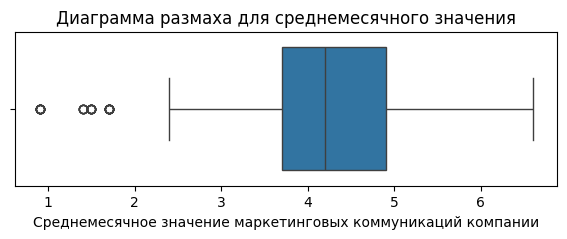

In [33]:
plt.figure(figsize=(7,2))
sns.boxplot(data=df_clients, x='маркет_актив_6_мес').set(
    xlabel='Среднемесячное значение маркетинговых коммуникаций компании',
    title="Диаграмма размаха для среднемесячного значения")
plt.show()

Значения ниже 2 выглядят как аномалии, но такие значения возможны хотя очень редко, т.е. это "выбросы", которые оставляем

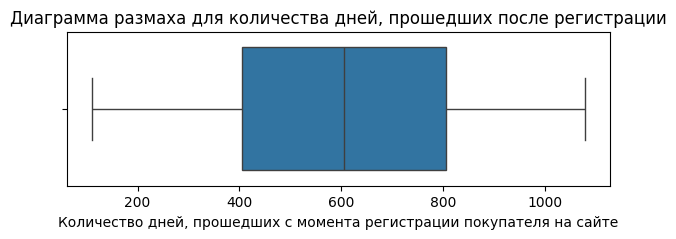

In [34]:
plt.figure(figsize=(7,2))
sns.boxplot(data=df_clients, x='длительность').set(
    xlabel='Количество дней, прошедших с момента регистрации покупателя на сайте',
    title="Диаграмма размаха для количества дней, прошедших после регистрации")
plt.show()

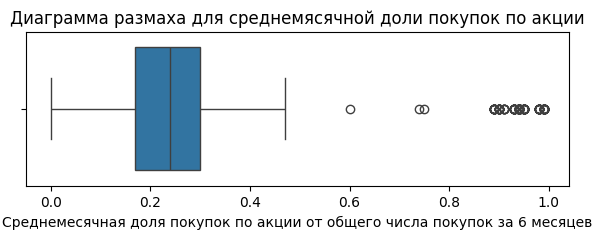

In [35]:
plt.figure(figsize=(7,2))
sns.boxplot(data=df_clients, x='акционные_покупки').set(
    xlabel='Среднемесячная доля покупок по акции от общего числа покупок за 6 месяцев',
    title="Диаграмма размаха для среднемясячной доли покупок по акции")
plt.show()

Значения доли от 0,6 до 1 выглядят аномальными, но такие значения могут быть

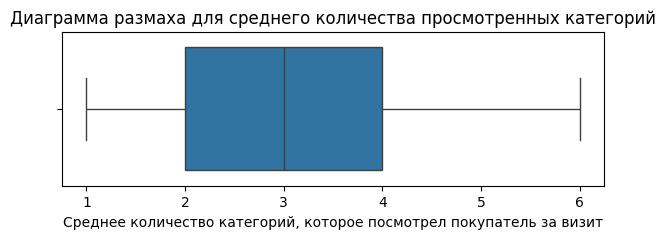

In [36]:
plt.figure(figsize=(7,2))
sns.boxplot(data=df_clients, x='средний_просмотр_категорий_за_визит').set(
    xlabel='Среднее количество категорий, которое посмотрел покупатель за визит',
    title="Диаграмма размаха для среднего количества просмотренных категорий")
plt.show()

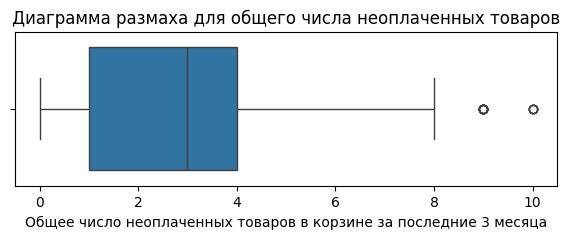

In [37]:
plt.figure(figsize=(7,2))
sns.boxplot(data=df_clients, x='неоплаченные_продукты_штук_квартал').set(
    xlabel='Общее число неоплаченных товаров в корзине за последние 3 месяца',
    title="Диаграмма размаха для общего числа неоплаченных товаров")
plt.show()

Значения 9 и 10 выглядят аномальными, но такие значения могут быть

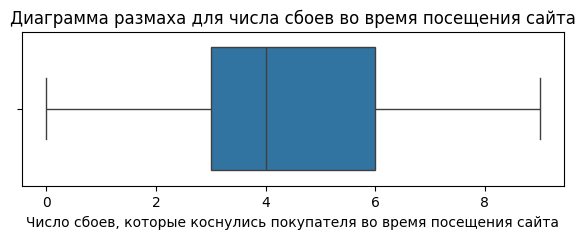

In [38]:
plt.figure(figsize=(7,2))
sns.boxplot(data=df_clients, x='ошибка_сервиса').set(
    xlabel='Число сбоев, которые коснулись покупателя во время посещения сайта',
    title="Диаграмма размаха для числа сбоев во время посещения сайта")
plt.show()

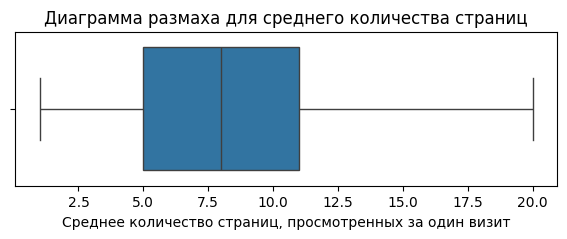

In [39]:
plt.figure(figsize=(7,2))
sns.boxplot(data=df_clients, x='страниц_за_визит').set(
    xlabel='Среднее количество страниц, просмотренных за один визит',
    title="Диаграмма размаха для среднего количества страниц")
plt.show()

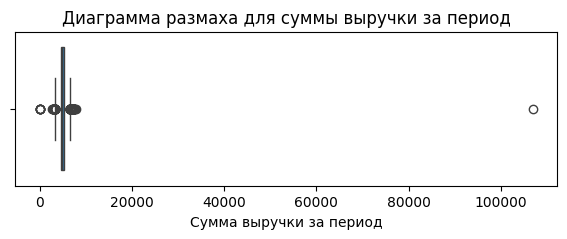

In [40]:
plt.figure(figsize=(7,2))
sns.boxplot(data=df_money, x='выручка').set(
    xlabel='Сумма выручки за период',
    title="Диаграмма размаха для суммы выручки за период")
plt.show()

Значение выручки более 100 000 является аномалией. Удалим ее.

In [41]:
df_money = df_money[df_money['выручка'] < 100000]

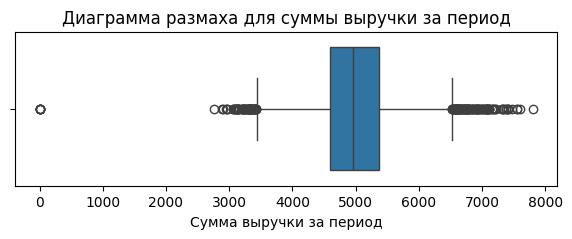

In [42]:
plt.figure(figsize=(7,2))
sns.boxplot(data=df_money, x='выручка').set(
    xlabel='Сумма выручки за период',
    title="Диаграмма размаха для суммы выручки за период")
plt.show()

Значение 0 выглядит аномально, но такое значение возможно

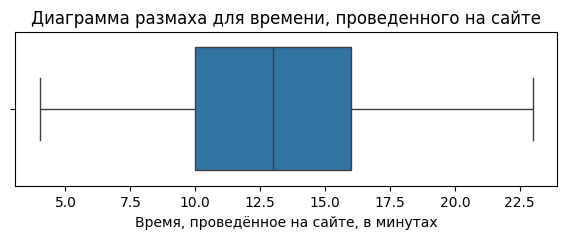

In [43]:
plt.figure(figsize=(7,2))
sns.boxplot(data=df_time, x='минут').set(
    xlabel='Время, проведённое на сайте, в минутах',
    title="Диаграмма размаха для времени, проведенного на сайте")
plt.show()

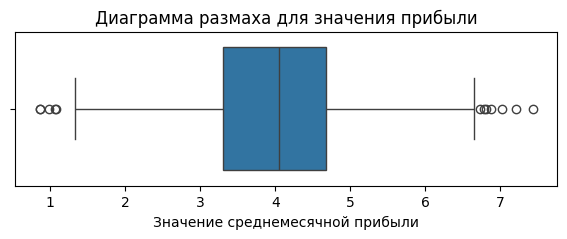

In [44]:
plt.figure(figsize=(7,2))
sns.boxplot(data=df_profit, x='прибыль').set(
    xlabel='Значение среднемесячной прибыли',
    title="Диаграмма размаха для значения прибыли")
plt.show()

Аномалий в датафреймах не обнаружено

## Исследовательский анализ данных

### Статистический анализ признаков

In [45]:
# создадим функцию построения гистограммы и диаграммы размаха для количественных признаков
def build_graph(num_feature, name):
    plt.figure(figsize=(15,3))
    plt.subplot(1, 2, 1)
    sns.histplot(num_feature)
    plt.title("Гистограмма")
    plt.xlabel(name)
    plt.ylabel('Количество')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=num_feature)
    plt.title("Диаграмма размаха")
    plt.xlabel(name)
    plt.show()

In [46]:
df_clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   покупательская_активность            1300 non-null   object 
 2   тип_сервиса                          1300 non-null   object 
 3   разрешить_сообщать                   1300 non-null   object 
 4   маркет_актив_6_мес                   1300 non-null   float64
 5   маркет_актив_тек_мес                 1300 non-null   int64  
 6   длительность                         1300 non-null   int64  
 7   акционные_покупки                    1300 non-null   float64
 8   популярная_категория                 1300 non-null   object 
 9   средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  ошибка_сервиса                

Построим гистограммы (для выявления бимодальности) и диаграммы размаха (для выявления выбросов и оценки разброса данных) для количественных признаков

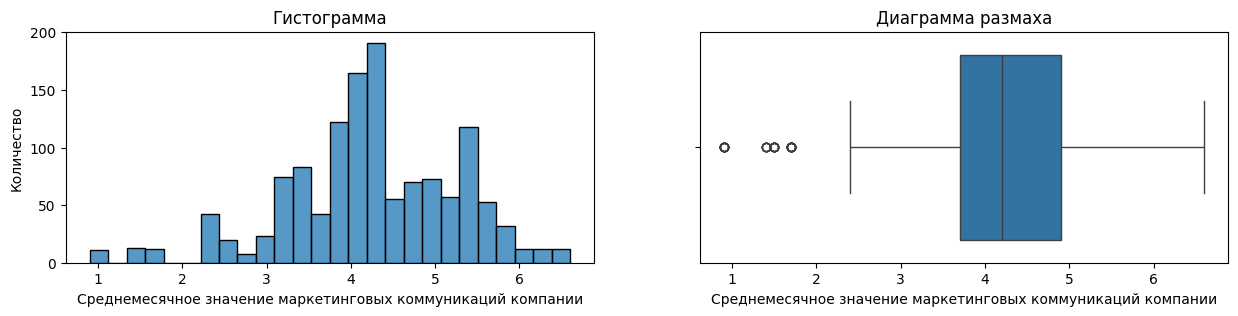

In [47]:
build_graph(df_clients['маркет_актив_6_мес'], 'Среднемесячное значение маркетинговых коммуникаций компании')

In [48]:
df_clients['маркет_актив_6_мес'].describe()

count    1300.000000
mean        4.253769
std         1.014814
min         0.900000
25%         3.700000
50%         4.200000
75%         4.900000
max         6.600000
Name: маркет_актив_6_мес, dtype: float64

Признак "Среднемесячное значение маркетинговых коммуникаций компании" содержит непрерывные переменные. Медиана и среднее значение примерно равны и равны 4,2, стандартное отклонение от них примерно равно 1. Есть подозрительно малые значения, но они не являются аномалиями.

Построим для этого признака гистограмму плотности частоты, т.к. она лучше описывает непрерывные переменные

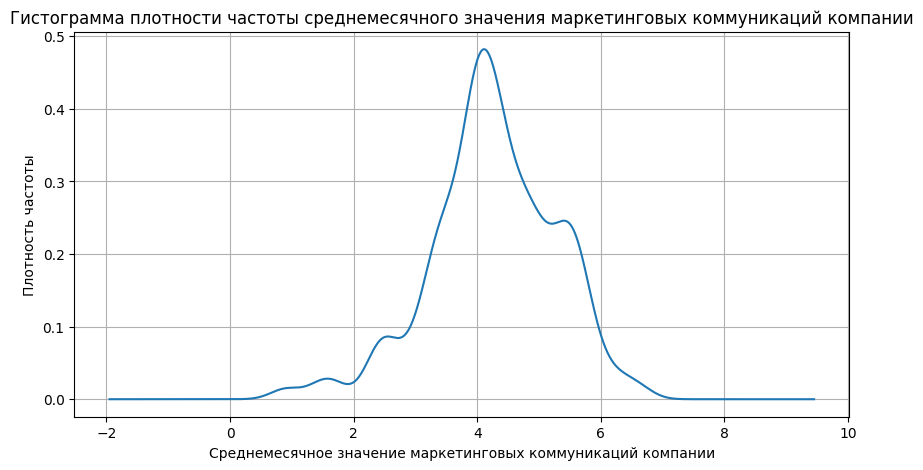

In [49]:
df_clients['маркет_актив_6_мес'].plot.kde(figsize=(10,5), grid=True)
plt.title("Гистограмма плотности частоты среднемесячного значения маркетинговых коммуникаций компании")
plt.xlabel('Среднемесячное значение маркетинговых коммуникаций компании')
plt.ylabel('Плотность частоты')
plt.show()

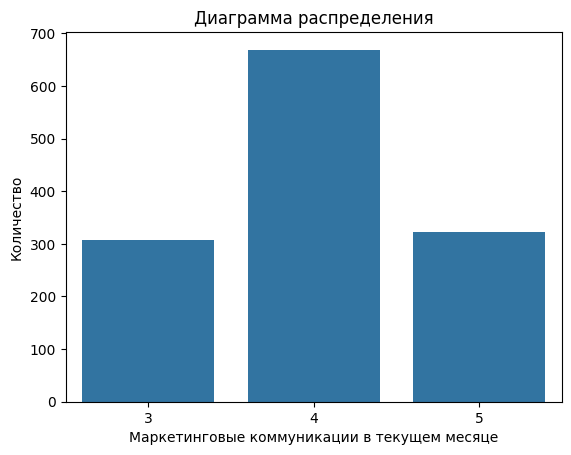

In [50]:
sns.countplot(data=df_clients, x='маркет_актив_тек_мес')
plt.title("Диаграмма распределения")
plt.xlabel('Маркетинговые коммуникации в текущем месяце')
plt.ylabel('Количество')
plt.show()

In [51]:
df_clients['маркет_актив_тек_мес'].describe()

count    1300.000000
mean        4.011538
std         0.696868
min         3.000000
25%         4.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: маркет_актив_тек_мес, dtype: float64

In [52]:
df_clients['маркет_актив_тек_мес'].mode()

0    4
Name: маркет_актив_тек_мес, dtype: int64

Признак "Количество маркетинговых коммуникаций в текущем месяце" содержит дискретные переменные. Мода, среднее значение и медиана равны 4. Значение 4 встречается в данных больше, чем другие значения (3 и 5) вместе взятые. Поэтому значения 3 и 5 выглядят аномальными, но не являются аномалиями

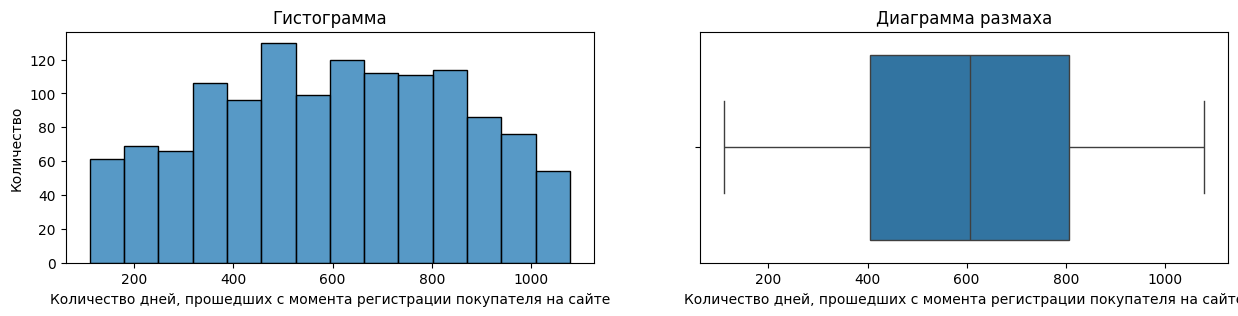

In [53]:
build_graph(df_clients['длительность'], 'Количество дней, прошедших с момента регистрации покупателя на сайте')

In [54]:
df_clients['длительность'].describe()

count    1300.000000
mean      601.898462
std       249.856289
min       110.000000
25%       405.500000
50%       606.000000
75%       806.000000
max      1079.000000
Name: длительность, dtype: float64

In [55]:
df_clients['длительность'].mode()

0    449
1    600
2    627
Name: длительность, dtype: int64

In [56]:
df_clients['длительность'].value_counts().head()

длительность
600    7
449    7
627    7
788    6
744    6
Name: count, dtype: int64

Признак "Количество дней, прошедших с момента регистрации покупателя на сайте" содержит дискретные переменные. Мода равна 449 600 и 627, медиана равна 606, среднее значение равно 602, стандартное отклонение от медианы примерно 250 дней.

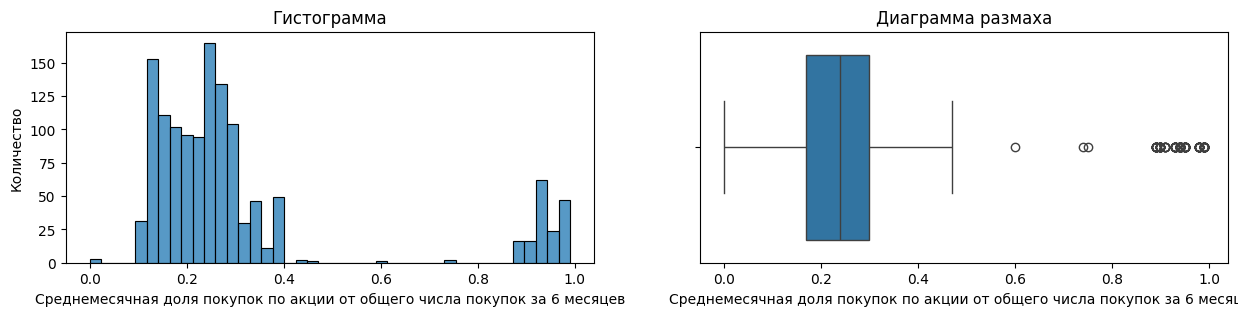

In [57]:
build_graph(df_clients['акционные_покупки'], 'Среднемесячная доля покупок по акции от общего числа покупок за 6 месяцев')

In [58]:
df_clients['акционные_покупки'].describe()

count    1300.000000
mean        0.319808
std         0.249843
min         0.000000
25%         0.170000
50%         0.240000
75%         0.300000
max         0.990000
Name: акционные_покупки, dtype: float64

Признак "Среднемесячная доля покупок по акции от общего числа покупок за 6 месяцев" содержит непрерывные переменные от 0 до 1. Медиана равна 0,24, среднее значение равно 0,32.

Построим для этого признака гистограмму плотности частоты, т.к. она лучше описывает непрерывные переменные

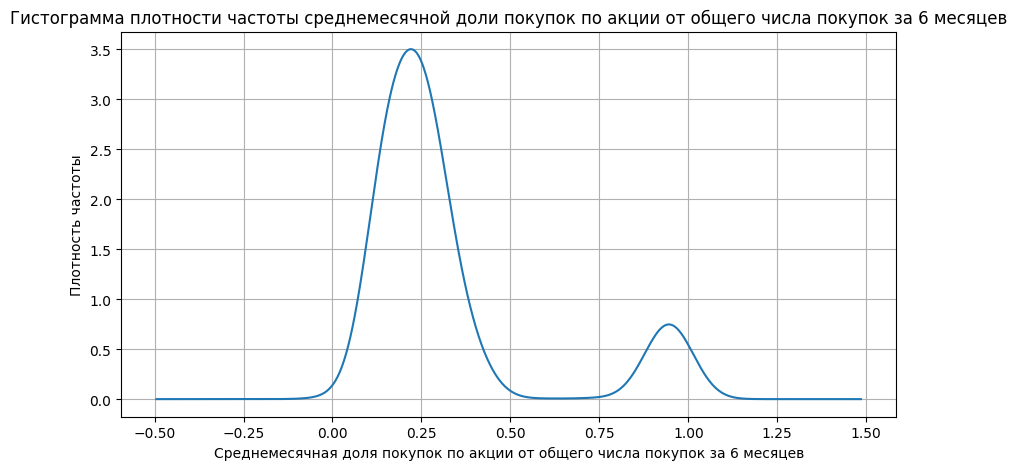

In [59]:
df_clients['акционные_покупки'].plot.kde(figsize=(10,5), grid=True)
plt.title("Гистограмма плотности частоты среднемесячной доли покупок по акции от общего числа покупок за 6 месяцев")
plt.xlabel('Среднемесячная доля покупок по акции от общего числа покупок за 6 месяцев')
plt.ylabel('Плотность частоты')
plt.show()

У этого признака набор данных имеет бимодальное распределение.

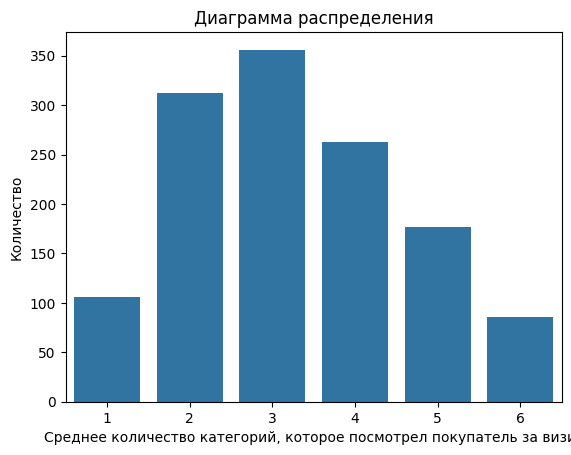

In [60]:
sns.countplot(data=df_clients, x='средний_просмотр_категорий_за_визит')
plt.title("Диаграмма распределения")
plt.xlabel('Среднее количество категорий, которое посмотрел покупатель за визит')
plt.ylabel('Количество')
plt.show()

In [61]:
df_clients['средний_просмотр_категорий_за_визит'].describe()

count    1300.00000
mean        3.27000
std         1.35535
min         1.00000
25%         2.00000
50%         3.00000
75%         4.00000
max         6.00000
Name: средний_просмотр_категорий_за_визит, dtype: float64

In [62]:
df_clients['средний_просмотр_категорий_за_визит'].mode()

0    3
Name: средний_просмотр_категорий_за_визит, dtype: int64

Признак "Среднее количество категорий, которое посмотрел покупатель за визит" содержит дискретные переменные. Мода и медиана равна 3, среднее значение равно 3,27.

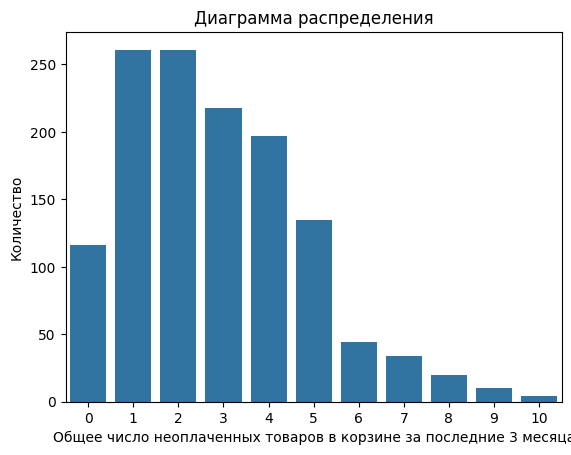

In [63]:
sns.countplot(data=df_clients, x='неоплаченные_продукты_штук_квартал')
plt.title("Диаграмма распределения")
plt.xlabel('Общее число неоплаченных товаров в корзине за последние 3 месяца')
plt.ylabel('Количество')
plt.show()

In [64]:
df_clients['неоплаченные_продукты_штук_квартал'].describe()

count    1300.000000
mean        2.840000
std         1.971451
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: неоплаченные_продукты_штук_квартал, dtype: float64

In [65]:
df_clients['неоплаченные_продукты_штук_квартал'].mode()

0    1
1    2
Name: неоплаченные_продукты_штук_квартал, dtype: int64

Признак "Общее число неоплаченных товаров в корзине за последние 3 месяца" содержит дискретные переменные. Мода равна 1 и 2, медиана равна 3, среднее значение равно 2,84

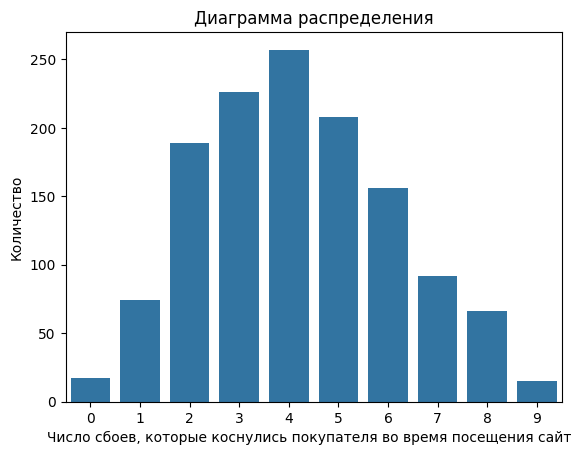

In [66]:
sns.countplot(data=df_clients, x='ошибка_сервиса')
plt.title("Диаграмма распределения")
plt.xlabel('Число сбоев, которые коснулись покупателя во время посещения сайта')
plt.ylabel('Количество')
plt.show()

In [67]:
df_clients['ошибка_сервиса'].describe()

count    1300.000000
mean        4.185385
std         1.955298
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max         9.000000
Name: ошибка_сервиса, dtype: float64

In [68]:
df_clients['ошибка_сервиса'].mode()

0    4
Name: ошибка_сервиса, dtype: int64

Признак "Число сбоев, которые коснулись покупателя во время посещения сайта" содержит дискретные переменные. Мода и медиана равна 4, среднее значение равно 4,2.

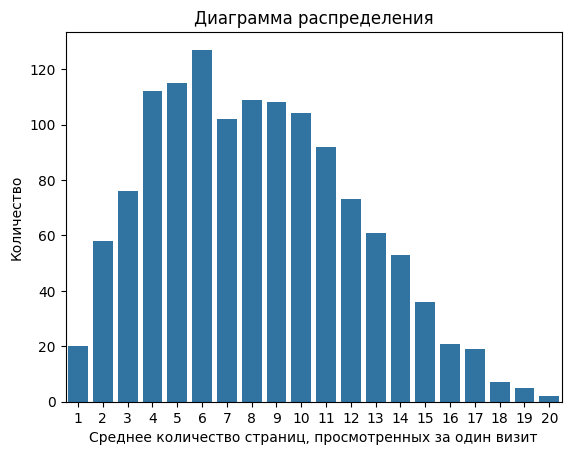

In [69]:
sns.countplot(data=df_clients, x='страниц_за_визит')
plt.title("Диаграмма распределения")
plt.xlabel('Среднее количество страниц, просмотренных за один визит')
plt.ylabel('Количество')
plt.show()

In [70]:
df_clients['страниц_за_визит'].describe()

count    1300.000000
mean        8.176923
std         3.978126
min         1.000000
25%         5.000000
50%         8.000000
75%        11.000000
max        20.000000
Name: страниц_за_визит, dtype: float64

In [71]:
df_clients['страниц_за_визит'].mode()

0    6
Name: страниц_за_визит, dtype: int64

Признак "Среднее количество страниц, просмотренных за один визит" содержит дискретные переменные. Мода равна 6, медиана равна 8, среднее значение равно 8,18.

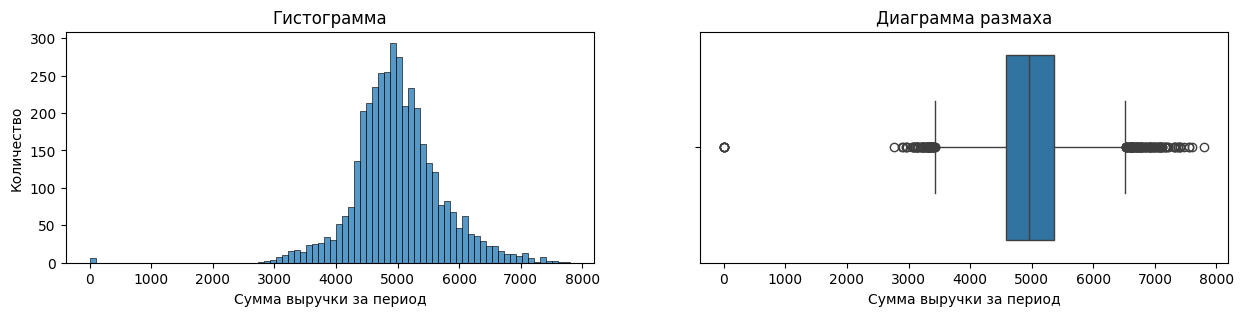

In [72]:
build_graph(df_money['выручка'], 'Сумма выручки за период')

In [73]:
df_money['выручка'].describe()

count    3899.00000
mean     4999.57743
std       706.99988
min         0.00000
25%      4590.10000
50%      4957.00000
75%      5363.00000
max      7799.40000
Name: выручка, dtype: float64

Признак "Сумма выручки за период" содержит непрерывные переменные. Медиана равна 4957, среднее значение равно 4999,6.

Построим для этого признака гистограмму плотности частоты, т.к. она лучше описывает непрерывные переменные

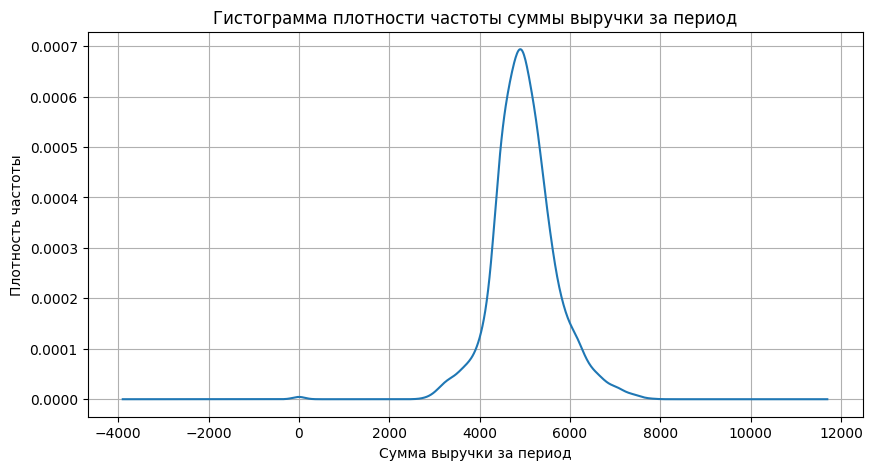

In [74]:
df_money['выручка'].plot.kde(figsize=(10,5), grid=True)
plt.title("Гистограмма плотности частоты суммы выручки за период")
plt.xlabel('Сумма выручки за период')
plt.ylabel('Плотность частоты')
plt.show()

Получилось нормальное распределение с математическим ожиданием примерно равным 5000

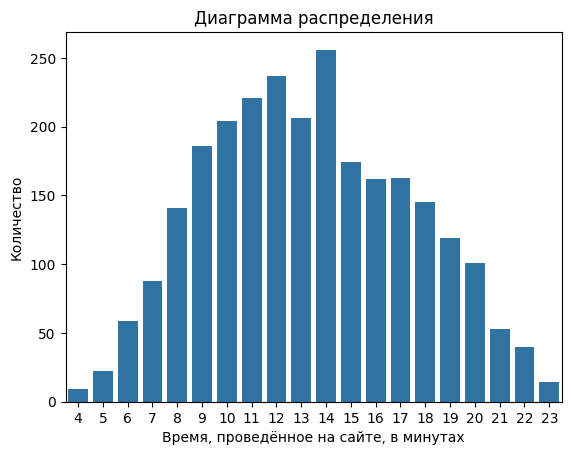

In [75]:
sns.countplot(data=df_time, x='минут')
plt.title("Диаграмма распределения")
plt.xlabel('Время, проведённое на сайте, в минутах')
plt.ylabel('Количество')
plt.show()

In [76]:
df_time['минут'].describe()

count    2600.000000
mean       13.336154
std         4.080198
min         4.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        23.000000
Name: минут, dtype: float64

In [77]:
df_time['минут'].mode()

0    14
Name: минут, dtype: int64

Признак "Время, проведённое на сайте, в минутах" содержит дискретные переменные. Видимо это время округленное до минут. Мода равна 14, медиана равна 13, среднее значение равно 13,34.

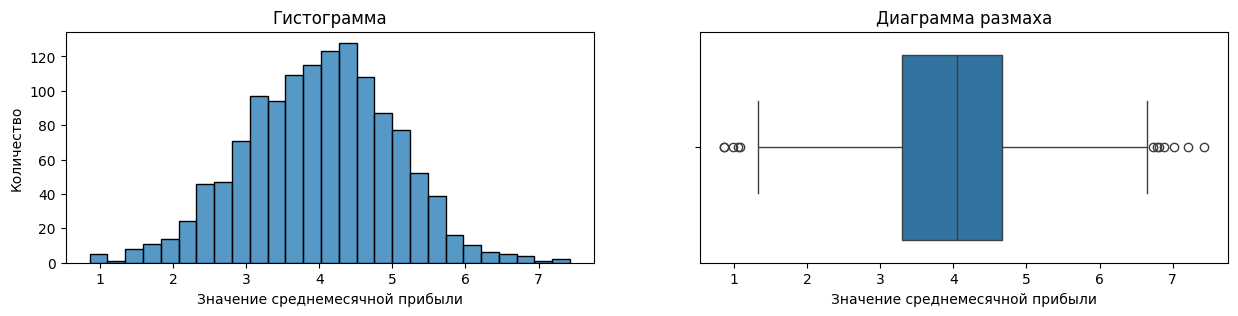

In [78]:
build_graph(df_profit['прибыль'], 'Значение среднемесячной прибыли')

In [79]:
df_profit['прибыль'].describe()

count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: прибыль, dtype: float64

Признак "Значение среднемесячной прибыли" содержит непрерывные признаки. Медиана и среднее значение примерно равны и равны 4.

Построим для этого признака гистограмму плотности частоты, т.к. она лучше описывает непрерывные переменные

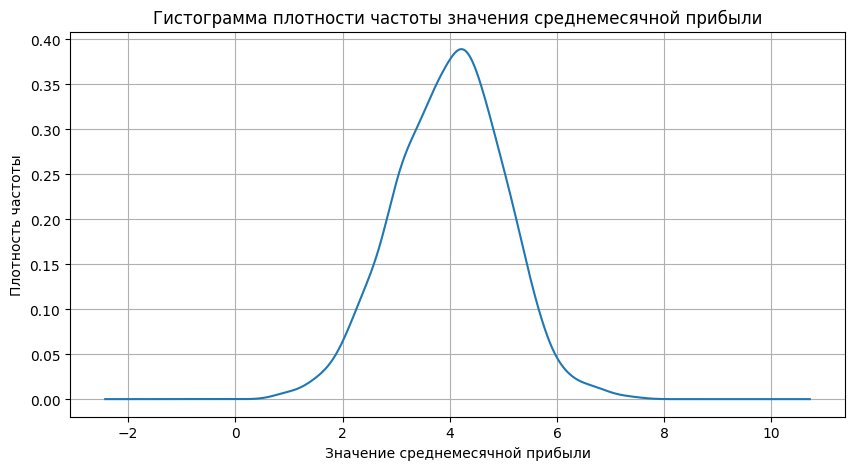

In [80]:
df_profit['прибыль'].plot.kde(figsize=(10,5), grid=True)
plt.title("Гистограмма плотности частоты значения среднемесячной прибыли")
plt.xlabel('Значение среднемесячной прибыли')
plt.ylabel('Плотность частоты')
plt.show()

Набор данных у этого признака имеет нормальное распределение с математическим ожиданием равным чуть больше 4.

Для категориальных признаков построим круговые диаграммы

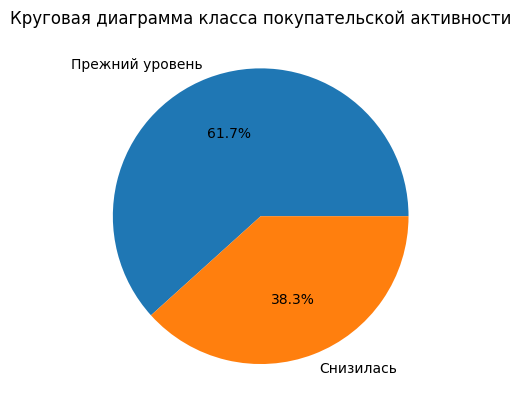

In [81]:
df_clients.groupby(by='покупательская_активность').agg('count')['id'].plot.pie(autopct='%.1f%%')
plt.title("Круговая диаграмма класса покупательской активности")
plt.ylabel("")
plt.show()

У целевого признака дисбаланс классов. Количество клиентов, у которых покупательская активность снизилась, почти в два раза меньше, чем клиентов, у которых покупательская активность осталась на прежнем уровне

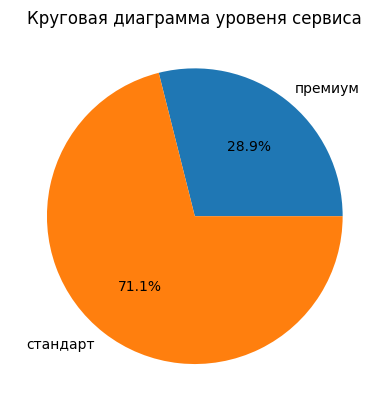

In [82]:
df_clients.groupby(by='тип_сервиса').agg('count')['id'].plot.pie(autopct='%.1f%%')
plt.title("Круговая диаграмма уровеня сервиса")
plt.ylabel("")
plt.show()

У признака "тип_сервиса" дисбаланс классов. Количество клиентов, у которых тип сервиса "стандарт", почти в раза больше чем "премиум"

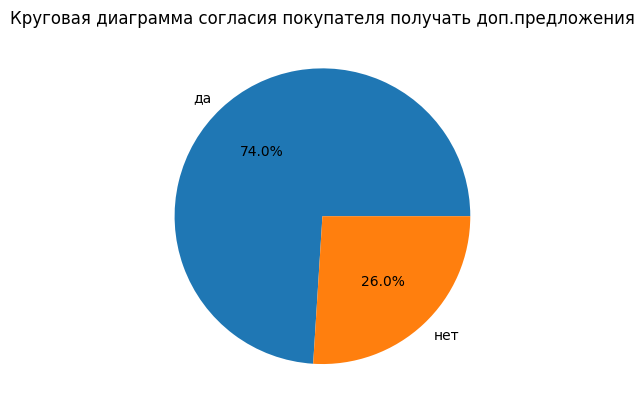

In [83]:
df_clients.groupby(by='разрешить_сообщать').agg('count')['id'].plot.pie(autopct='%.1f%%')
plt.title("Круговая диаграмма согласия покупателя получать доп.предложения")
plt.ylabel("")
plt.show()

У признака "разрешить_сообщать" тоже дисбаланс классов. Разница примерно в 3 раза.

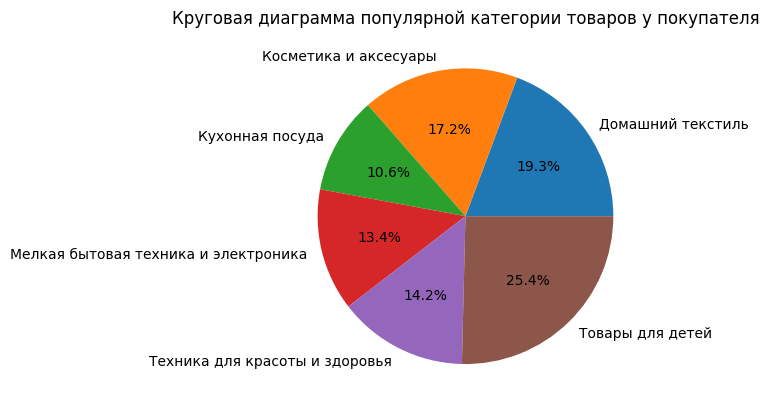

In [84]:
df_clients.groupby(by='популярная_категория').agg('count')['id'].plot.pie(autopct='%.1f%%')
plt.title("Круговая диаграмма популярной категории товаров у покупателя")
plt.ylabel("")
plt.show()

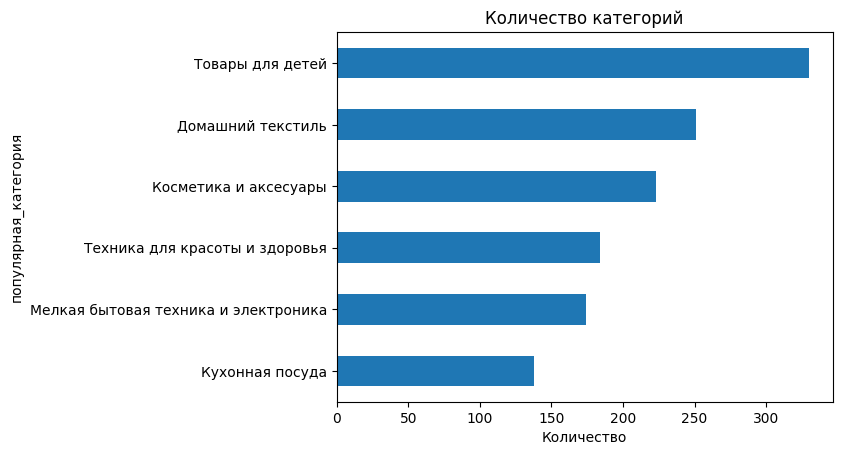

In [85]:
df_clients['популярная_категория'].value_counts(ascending=True).plot(kind='barh')
plt.title("Количество категорий")
plt.xlabel('Количество')
plt.show()

Количество клиентов, у которых популярная категория "товары для детей", в два раза больше, чем клиентов, у которых популярная категория "кухонная посуда"

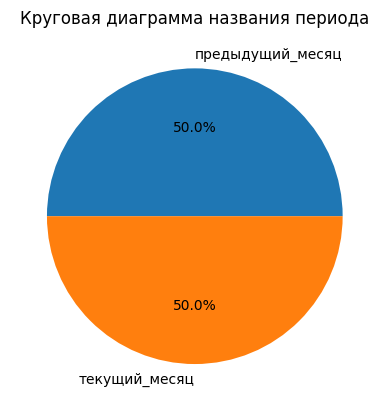

In [86]:
df_time.groupby(by='период').agg('count')['id'].plot.pie(autopct='%.1f%%')
plt.title("Круговая диаграмма названия периода")
plt.ylabel("")
plt.show()

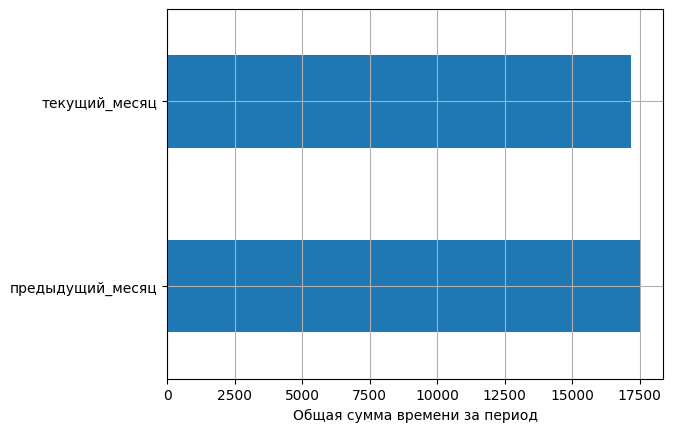

In [87]:
df_time.groupby(by='период')['минут'].sum().plot.barh(grid=True)
plt.xlabel('Общая сумма времени за период')
plt.ylabel('')
plt.show()

Общая сумма времени, проведенное на сайте, примерно одинаковое по всем периодам

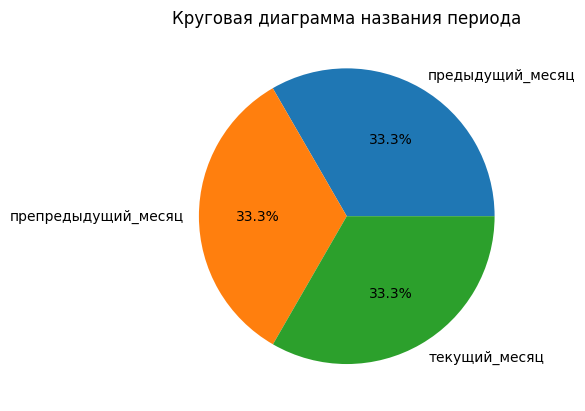

In [88]:
df_money.groupby(by='период').agg('count')['id'].plot.pie(autopct='%.1f%%')
plt.title("Круговая диаграмма названия периода")
plt.ylabel("")
plt.show()

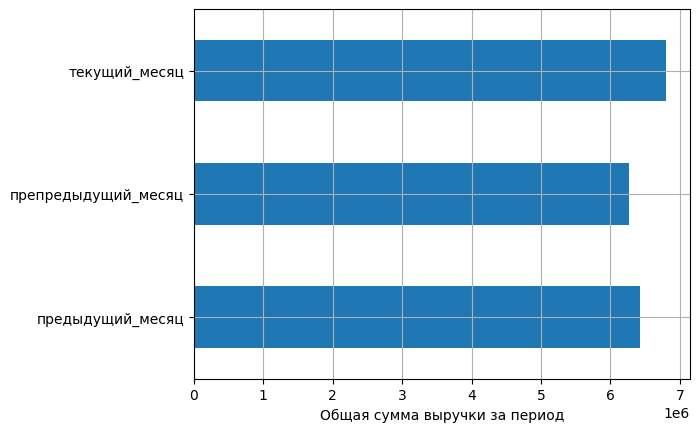

In [89]:
df_money.groupby(by='период')['выручка'].sum().plot.barh(grid=True)
plt.xlabel('Общая сумма выручки за период')
plt.ylabel('')
plt.show()

Общая сумма выручки по всем периодам примерно одинаковая

Отберем клиентов с покупательской активностью не менее трёх месяцев, то есть таких, которые что-либо покупали в этот период

In [90]:
id_null = df_money[df_money['выручка'] == 0]['id'].unique()

In [91]:
df_clients = df_clients[~df_clients['id'].isin(id_null)]
df_money = df_money[~df_money['id'].isin(id_null)]

In [92]:
df_money.head()

,id,период,выручка
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6
5,215349,предыдущий_месяц,5216.0
6,215350,препредыдущий_месяц,4826.0
7,215350,текущий_месяц,5058.4


In [93]:
df_clients.shape[0]

1297

Количество клиентов с покупательской активность не менее трёх месяцев получилось 1297

В наборах данных есть признаки с непрерывными и дискретными числовыми переменными. Некоторые значения выглядят аномально, но не являются аномалиями. Большинство значений признаков с непрерывными переменными имеют нормальное распределение. Значения у признака «Среднемесячная доля покупок по акции от общего числа покупок за 6 месяцев» имеет бимодальное распределение.

## Объединение таблиц

In [94]:
# Выведем список id клиентов, которые присутсивуют в df_clients, но отсутствуют в df_money
df_clients['id'][~df_clients['id'].isin(df_money['id'])]

Series([], Name: id, dtype: int64)

Таких id нет, значит после объединения никакие данные не потеряются

In [95]:
# Для обучения столбец id не нужен, поэтому сделаем эти значения индексами
df_clients = df_clients.set_index('id')

In [96]:
# Подготовим таблицу для объединения
df_money = df_money.pivot_table(index='id', columns='период', values='выручка', aggfunc='sum')

In [97]:
df_money = df_money.fillna(0)

In [98]:
df_money.head(3)

период,предыдущий_месяц,препредыдущий_месяц,текущий_месяц
id,,,
215349,5216.0,4472.0,4971.6
215350,5457.5,4826.0,5058.4
215351,6158.0,4793.0,6610.4


In [99]:
# Объединим таблицы df_clients и df_money. В итоговой таблице сделаем отдельный столбец для каждого периода
df_clients = df_clients.join(df_money)

In [100]:
df_clients.head(3)

,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,предыдущий_месяц,препредыдущий_месяц,текущий_месяц
id,,,,,,,,,,,,,,,
215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6
215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4
215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4


In [101]:
# Подготовим таблицу для объединения
df_time = df_time.pivot_table(index='id', columns='период', values='минут', aggfunc='sum')

In [102]:
df_time.head(3)

период,предыдущий_месяц,текущий_месяц
id,,
215348,13,14
215349,12,10
215350,8,13


In [103]:
# Объединим таблицы df_clients и df_time. В итоговой таблице сделаем отдельный столбец для каждого периода
df_clients = df_clients.join(df_time, lsuffix = '_выручка', rsuffix= '_минут')

In [104]:
df_clients.head(3)

,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,предыдущий_месяц_выручка,препредыдущий_месяц,текущий_месяц_выручка,предыдущий_месяц_минут,текущий_месяц_минут
id,,,,,,,,,,,,,,,,,
215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10
215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13
215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13


Добавилось 5 столбцов из таблиц df_money и df_time

In [105]:
# Переименум столбец "препредыдущий_месяц" по аналогии с другими столбцами
df_clients = df_clients.rename(columns={
    'препредыдущий_месяц': 'препредыдущий_месяц_выручка'
})

In [106]:
df_clients.head(3)

,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,предыдущий_месяц_выручка,препредыдущий_месяц_выручка,текущий_месяц_выручка,предыдущий_месяц_минут,текущий_месяц_минут
id,,,,,,,,,,,,,,,,,
215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10
215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13
215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13


## Корреляционный анализ

Будем использовать корреляцию Спирмена, т.к. в данных есть ненормальное распределение и выбросы

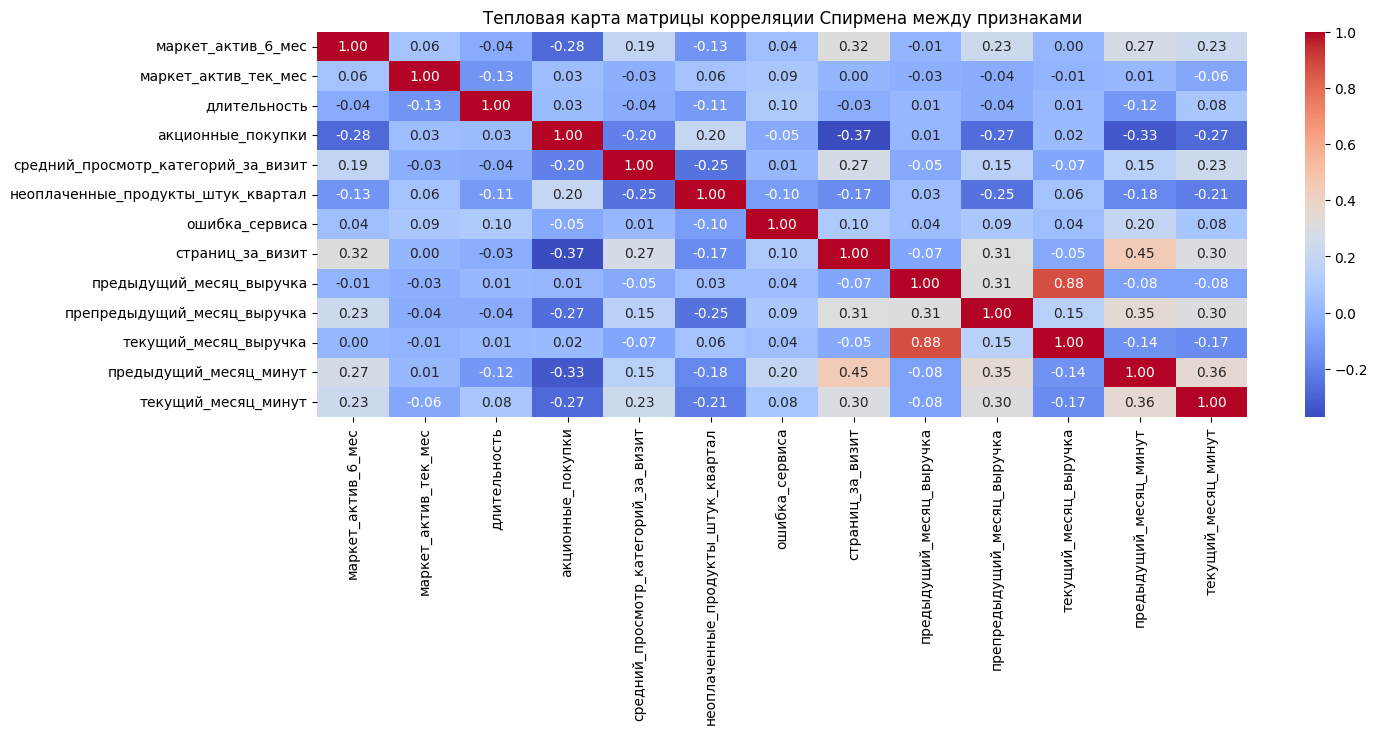

In [108]:
plt.figure(figsize=(15,5))
sns.heatmap(
    df_clients.corr(method='spearman', numeric_only=True), 
    cmap='coolwarm', 
    annot=True,
    fmt='.2f').set(title="Тепловая карта матрицы корреляции Спирмена между признаками")
plt.show()

Между признаками "текущий_месяц_выручка" и "предыдущий_месяц_выручка" есть мультиколлинеарность, т.к. между ними высокое значение корреляции (0.88). Для устранения мультиколлинеарности удалим признак "предыдущий_месяц_выручка"

In [109]:
df_clients = df_clients.drop(['предыдущий_месяц_выручка'], axis=1)

In [110]:
df_clients.head(3)

,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,препредыдущий_месяц_выручка,текущий_месяц_выручка,предыдущий_месяц_минут,текущий_месяц_минут
id,,,,,,,,,,,,,,,,
215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,4971.6,12,10
215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5058.4,8,13
215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6610.4,11,13


Используем библиотеку phik для подсчёта корреляции между признаками разных типов данных

In [111]:
interval_cols = ['маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность', 'акционные_покупки', 'средний_просмотр_категорий_за_визит', 'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса', 'страниц_за_визит', 'препредыдущий_месяц_выручка', 'текущий_месяц_выручка', 'предыдущий_месяц_минут', 'текущий_месяц_минут']

In [112]:
phik_overview = df_clients.phik_matrix(interval_cols=interval_cols)

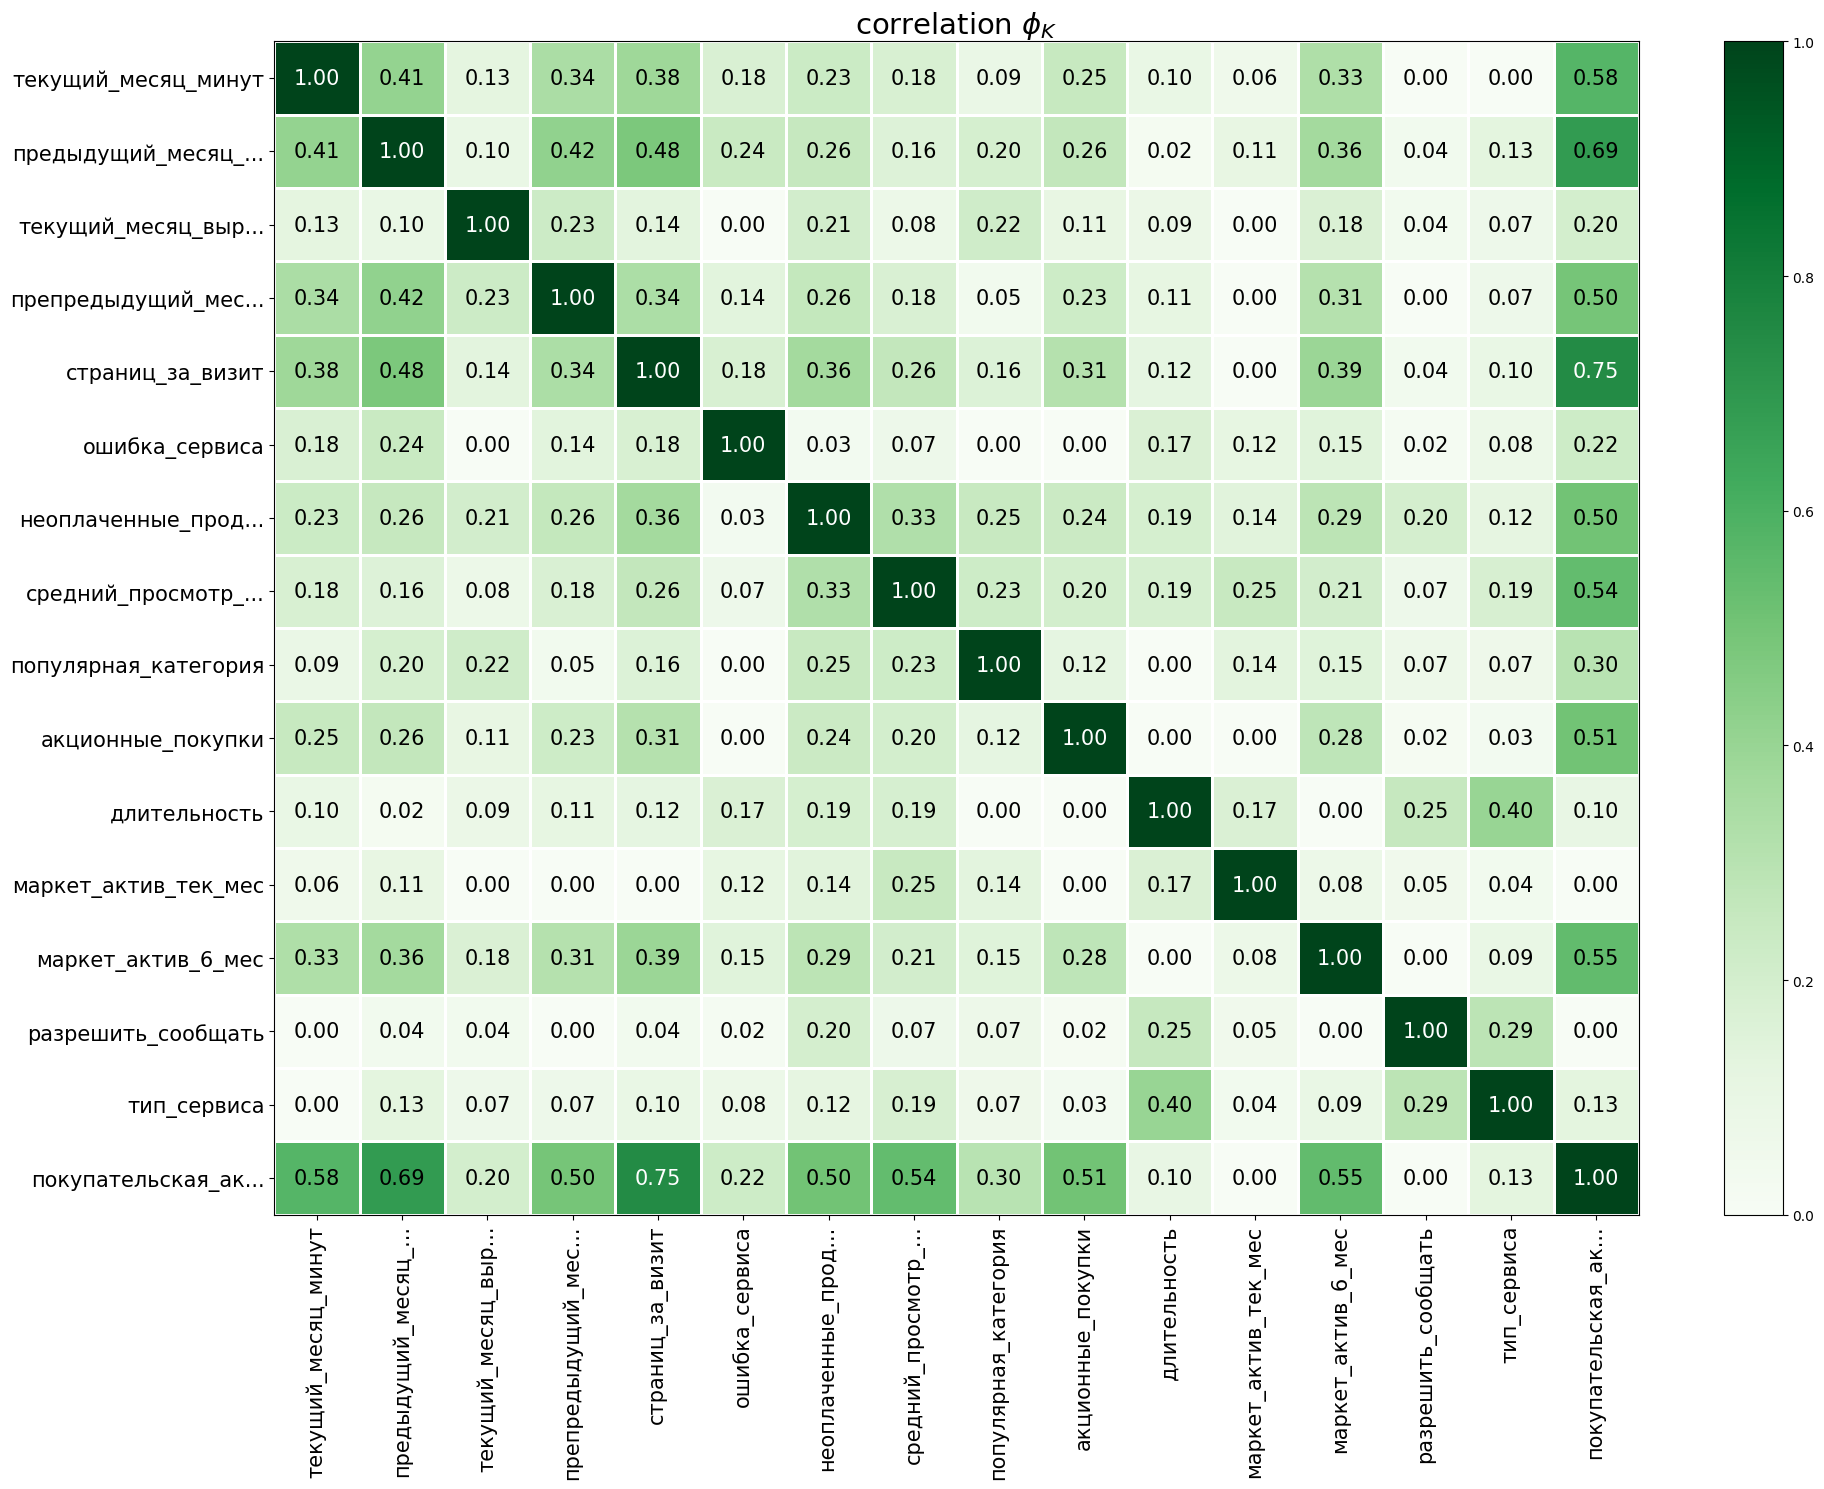

In [113]:
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

Между признаками мультиколлинеарности нет.

In [114]:
phik_overview.columns

Index(['покупательская_активность', 'тип_сервиса', 'разрешить_сообщать',
       'маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность',
       'акционные_покупки', 'популярная_категория',
       'средний_просмотр_категорий_за_визит',
       'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса',
       'страниц_за_визит', 'препредыдущий_месяц_выручка',
       'текущий_месяц_выручка', 'предыдущий_месяц_минут',
       'текущий_месяц_минут'],
      dtype='object')

В наборе данных была мультиколлинеарность между признаками "текущий_месяц_выручка" и "предыдущий_месяц_выручка". Для избавления мультиколлинеарности удалили признак "предыдущий_месяц_выручка".

## Использование пайплайнов

Будем использовать метрику ROC-AUC, т.к. это бинартная классификация, мы не знаем какой класс угадывать более выгодно и объектов с одним значением целевого признака больше, чем с другими. При бинарной классификации и дисбалансе классов целевого признака лучше подходит метрика ROC-AUC.

In [115]:
# Преобразуем целевой признак в бинарное значение. 
# Заменим значение "снизилась" на значение 1, а значение "Прежний_уровень" на 0
df_clients['покупательская_активность'] = df_clients['покупательская_активность'].apply(lambda x: 1 if x == 'Снизилась' else 0)

In [116]:
df_clients.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1297 entries, 215349 to 216647
Data columns (total 16 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   покупательская_активность            1297 non-null   int64  
 1   тип_сервиса                          1297 non-null   object 
 2   разрешить_сообщать                   1297 non-null   object 
 3   маркет_актив_6_мес                   1297 non-null   float64
 4   маркет_актив_тек_мес                 1297 non-null   int64  
 5   длительность                         1297 non-null   int64  
 6   акционные_покупки                    1297 non-null   float64
 7   популярная_категория                 1297 non-null   object 
 8   средний_просмотр_категорий_за_визит  1297 non-null   int64  
 9   неоплаченные_продукты_штук_квартал   1297 non-null   int64  
 10  ошибка_сервиса                       1297 non-null   int64  
 11  страниц_за_визит            

In [117]:
X = df_clients.drop(['покупательская_активность'], axis=1)
y = df_clients['покупательская_активность']

In [118]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

In [119]:
print(X_train.shape, X_test.shape)

(972, 15) (325, 15)


In [120]:
# создаём списки с названиями признаков
ohe_columns = ['разрешить_сообщать', 'популярная_категория']
ord_columns = ['тип_сервиса']
num_columns = X.select_dtypes(include='number').columns.tolist()

In [121]:
num_columns

['маркет_актив_6_мес',
 'маркет_актив_тек_мес',
 'длительность',
 'акционные_покупки',
 'средний_просмотр_категорий_за_визит',
 'неоплаченные_продукты_штук_квартал',
 'ошибка_сервиса',
 'страниц_за_визит',
 'препредыдущий_месяц_выручка',
 'текущий_месяц_выручка',
 'предыдущий_месяц_минут',
 'текущий_месяц_минут']

In [122]:
# создаём пайплайн для подготовки признаков из списка ohe_columns: OHE-кодирование
ohe_pipe = Pipeline([('ohe', OneHotEncoder(drop='first', sparse_output=False))])

In [123]:
# создаём пайплайн для подготовки признаков из списка ord_columns: Ordinal-кодирование
ord_pipe = Pipeline(
    [('ord',  OrdinalEncoder(
                categories=[
                    ['премиум', 'стандарт'], 
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
    ]
)

In [124]:
# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

In [125]:
# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

In [126]:
param_grid = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2,7),
        'models__max_features': range(2,7),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    
    # словарь для модели KNeighborsClassifier() 
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2,5),
        'models__metric': ['euclidean', 'cityblock'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },

    # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1,7),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },

    # словарь для модели SVC()
    {
        'models': [SVC(
            random_state=RANDOM_STATE 
        )],
        'models__kernel': ['rbf', 'linear', 'sigmoid'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
]

In [127]:
# Для подбора гиперпараметров используем RandomizedSearchCV, 
# т.к. он подбирает гиперпараметры быстрее по сравнению с OptunaSearchCV и GridSearchCV
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    n_iter=15
)

In [128]:
randomized_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('ohe',
                                                                                                OneHotEncoder(drop='first',
                                                                                                              sparse_output=False))]),
                                                                               ['разрешить_сообщать',
                                                                                'популярная_категория']),
                                                                              ('ord',
                                                                               Pipeline(steps=[('ord',
                                                                                                OrdinalEncoder(categories=[['премиум',
                                                                                                                            'стандарт']],
                                                                                                               handle_unknown='use...
                                        {'models': [LogisticRegression(penalty='l1',
                                                                       random_state=10,
                                                                       solver='liblinear')],
                                         'models__C': range(1, 7),
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               'passthrough']},
                                        {'models': [SVC(random_state=10)],
                                         'models__kernel': ['rbf', 'linear',
                                                            'sigmoid'],
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               'passthrough']}],
                   random_state=10, scoring='roc_auc')

In [129]:
print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика лучшей модели по кросс-валидации:', randomized_search.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['разрешить_сообщать',
                                                   'популярная_категория']),
                                                 ('ord',
                                                  Pipeline(steps=[('ord',
                                                                   OrdinalEncoder(categories=[['премиум',
                                                                                               'стандарт']],
                                               

In [130]:
y_test_pred = randomized_search.predict_proba(X_test)[:,1]
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test.to_list(), y_test_pred)}')

Метрика ROC-AUC на тестовой выборке: 0.8989728775477451


Лучшая точность получилась у модели логистической регрессии.

## Анализ важности признаков

### Оценим важность признаков для лучшей модели

In [131]:
features_names = randomized_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out() 

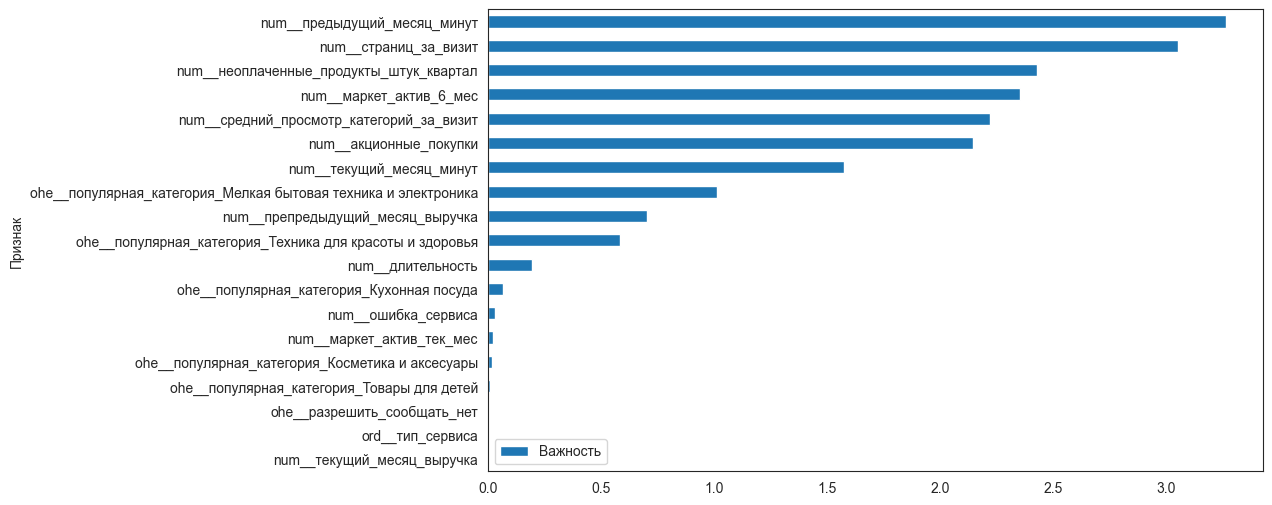

In [132]:
coefficients = randomized_search.best_estimator_.named_steps['models'].coef_[0]
feature_importance = pd.DataFrame({'Признак': features_names, 'Важность': np.abs(coefficients)})
feature_importance = feature_importance.sort_values(by='Важность', ascending=True)
sns.set_style('white')
feature_importance.plot(x='Признак', y='Важность', kind='barh', figsize=(10, 6))
plt.show()

Судя по коэффициентам лучшей модели (логистической регрессии) наиблее важные признаки "предыдущий_месяц_минут",  "страниц_за_визит" и "акционные покупки". Наименее важными признаками являются "текущий_месяц_выручка", "тип_сервиса"

### Оценим и построим важность признаков с помощью метода SHAP

In [133]:
X_preproc = pd.DataFrame(randomized_search.best_estimator_.named_steps['preprocessor'].transform(X_train),
                         columns=features_names)

In [134]:
explainer = shap.LinearExplainer(randomized_search.best_estimator_.named_steps['models'], 
                                 X_preproc)

In [135]:
shap_values = explainer(X_preproc)

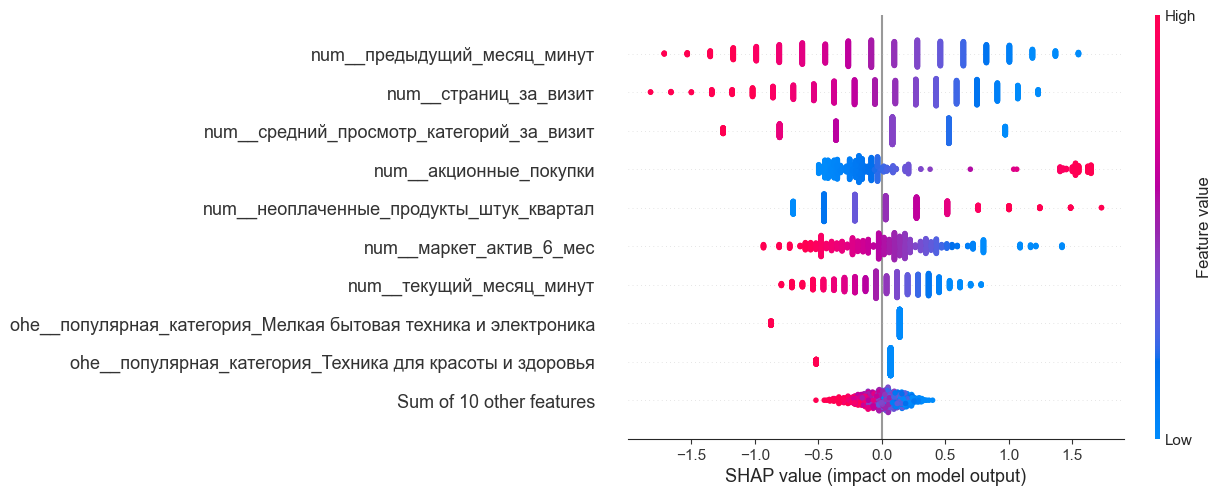

In [136]:
shap.plots.beeswarm(shap_values)

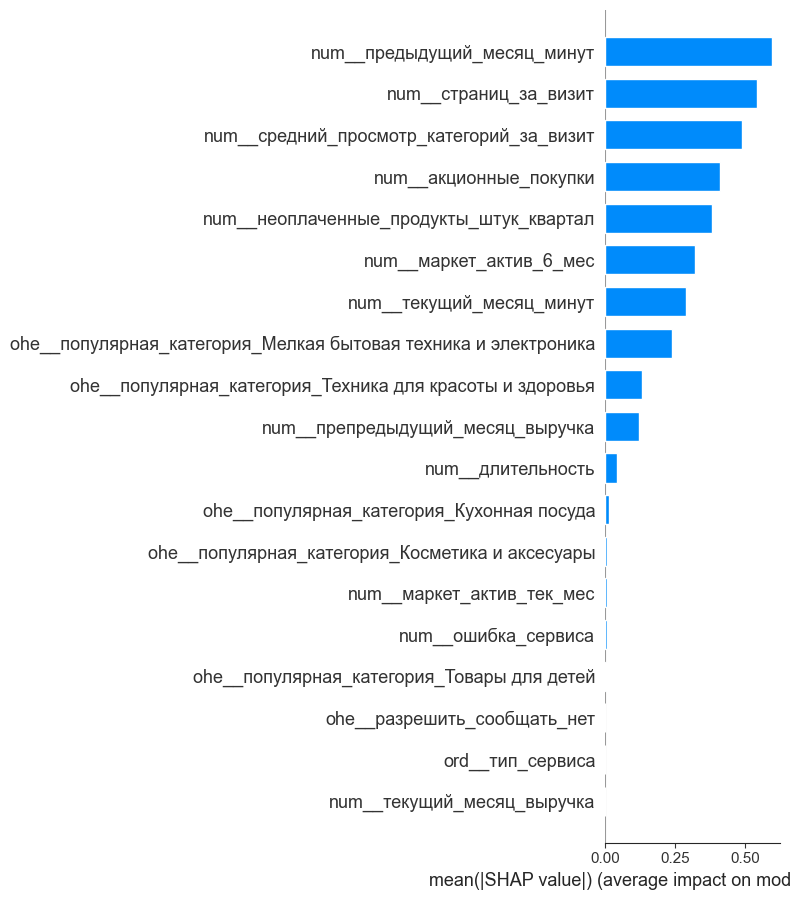

In [137]:
shap.summary_plot(shap_values, X_preproc, plot_type='bar')

Признаки "тип_сервиса" и "текущий_месяц_выручка" мало значимы для модели.
Больше всего на целевой признак влияют признаки "предыдущий_месяц_минут", "страниц_за_визит", "акционные_покупки" и "средний_просмотр_категорий_за_визит". При этом большие значения признаков "предыдущий_месяц_минут", "страниц_за_визит" и "средний_просмотр_категорий_за_визит" склоняют модель отнести объекты к классу 0, т.е. покупательская активность останется на прежнем уровне. Большие значения признака "акционные_покупки" склоняют модель отнести объекты к классу 1, т.е. покупательская активность снизится.

Таким образом, признаки, которые указывают на то что покупательская активность снизится это:
- малое количество времени проведенное на сайте в предыдущем месяце,
- малое среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца,
- малое количество категорий, которые покупатель просмотрел за визит в течение последнего месяца,
- большая среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев

## Сегментация покупателей

Добавим в набор данных поле с вероятностью предсказания снижения покупательской активности

In [138]:
X['predict'] = randomized_search.best_estimator_.predict_proba(X)[:,1]

И добавим данные из набора данных о среднемесячной прибыли по покупателям

In [139]:
df_profit = df_profit.set_index('id')

In [140]:
X = X.join(df_profit)

In [141]:
X.head(3)

,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,препредыдущий_месяц_выручка,текущий_месяц_выручка,предыдущий_месяц_минут,текущий_месяц_минут,predict,прибыль
id,,,,,,,,,,,,,,,,,
215349,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,4971.6,12,10,0.844178,4.16
215350,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5058.4,8,13,0.341173,3.13
215351,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6610.4,11,13,0.789246,4.87


Построим диаграммы рассеяния для вероятности снижения покупательской активности и прибыльности покупателей

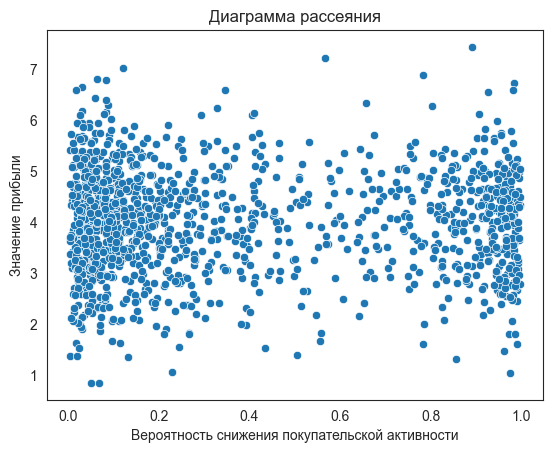

In [142]:
sns.scatterplot(data=X, x='predict', y='прибыль').set(
            title="Диаграмма рассеяния",
            xlabel='Вероятность снижения покупательской активности',
            ylabel='Значение прибыли')
plt.show()

Выберем группу покупателей с высокой вероятностью снижения покупательской активности и значением прибыли от 2 до 6, т.к. в этом диапазоне большая плотность покупателей

In [143]:
# Сделаем срез таких данных. Назовем их "Группа 1"
df_group_1 = X.query('predict > 0.7 and прибыль > 2 and прибыль < 6')

In [144]:
# И для сравнения создадим группу покупателей с такой же прибылью, 
# но с низкой вероятностью снижения покупательской активности. Назовем их "Группа 2"
df_group_2 = X.query('predict < 0.3 and прибыль > 2 and прибыль < 6')

In [145]:
# И создадим третью группу, по которым прогноз снижения покупательской активности около 50%
df_group_3 = X.query('predict > 0.3 and predict < 0.7')

Сравним эти группы

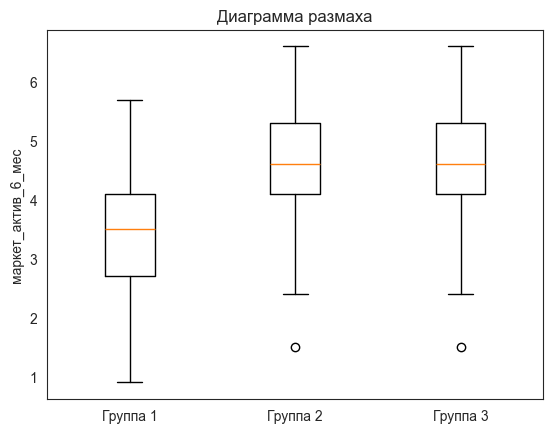

In [146]:
plt.boxplot([df_group_1['маркет_актив_6_мес'], 
             df_group_2['маркет_актив_6_мес'],
             df_group_2['маркет_актив_6_мес']], 
            labels=['Группа 1', 'Группа 2', 'Группа 3'])
plt.title('Диаграмма размаха')
plt.ylabel('маркет_актив_6_мес')
plt.show()

У второй и третьей групп по сравнению с первой группой выше среднемесячные значения маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев

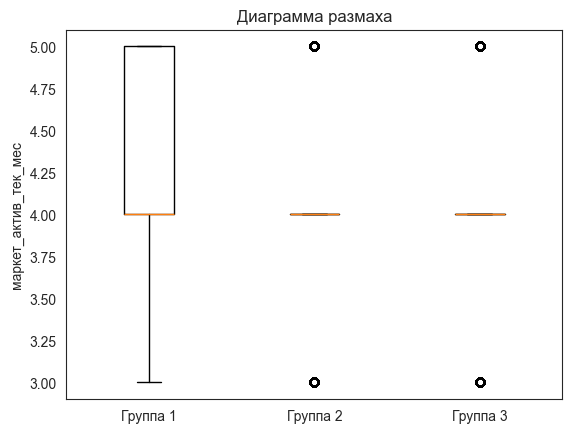

In [147]:
plt.boxplot([df_group_1['маркет_актив_тек_мес'], 
             df_group_2['маркет_актив_тек_мес'],
             df_group_2['маркет_актив_тек_мес']], 
            labels=['Группа 1', 'Группа 2', 'Группа 3'])
plt.title('Диаграмма размаха')
plt.ylabel('маркет_актив_тек_мес')
plt.show()

In [148]:
df_group_1['маркет_актив_тек_мес'].value_counts(normalize=True)

маркет_актив_тек_мес
4    0.511765
5    0.258824
3    0.229412
Name: proportion, dtype: float64

In [149]:
df_group_2['маркет_актив_тек_мес'].value_counts(normalize=True)

маркет_актив_тек_мес
4    0.532684
5    0.240612
3    0.226704
Name: proportion, dtype: float64

In [150]:
df_group_3['маркет_актив_тек_мес'].value_counts(normalize=True)

маркет_актив_тек_мес
4    0.497354
3    0.291005
5    0.211640
Name: proportion, dtype: float64

Количество маркетинговых коммуникаций в текущем месяце пропорционально одинаковое для всех групп

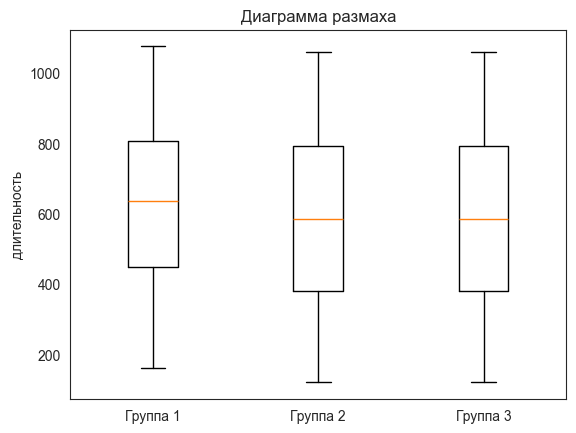

In [151]:
plt.boxplot([df_group_1['длительность'], 
             df_group_2['длительность'],
             df_group_2['длительность']], 
            labels=['Группа 1', 'Группа 2', 'Группа 3'])
plt.title('Диаграмма размаха')
plt.ylabel('длительность')
plt.show()

По количеству дней, прошедших с момента регистрации покупателя на сайте, группы почти не отличаются

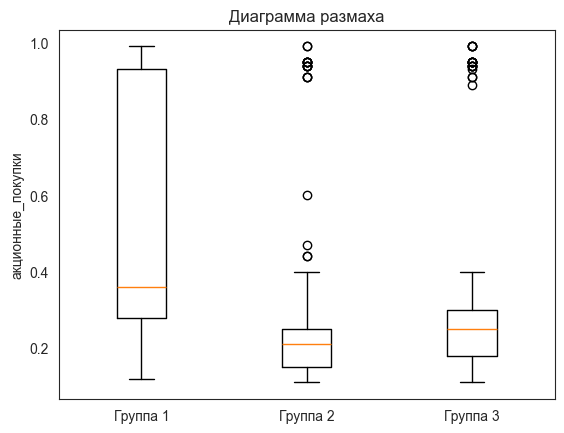

In [152]:
plt.boxplot([df_group_1['акционные_покупки'], 
             df_group_2['акционные_покупки'],
             df_group_3['акционные_покупки']], 
            labels=['Группа 1', 'Группа 2', 'Группа 3'])
plt.title('Диаграмма размаха')
plt.ylabel('акционные_покупки')
plt.show()

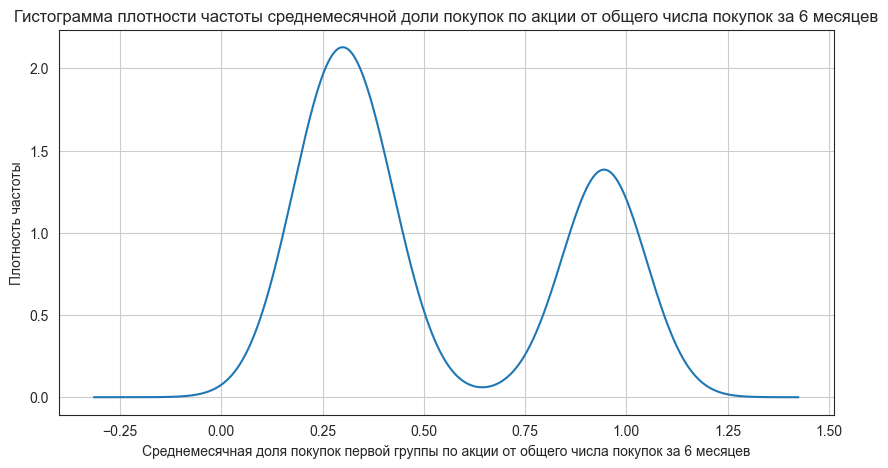

In [153]:
df_group_1['акционные_покупки'].plot.kde(figsize=(10,5), grid=True)
plt.title("Гистограмма плотности частоты среднемесячной доли покупок по акции от общего числа покупок за 6 месяцев")
plt.xlabel('Среднемесячная доля покупок первой группы по акции от общего числа покупок за 6 месяцев')
plt.ylabel('Плотность частоты')
plt.show()

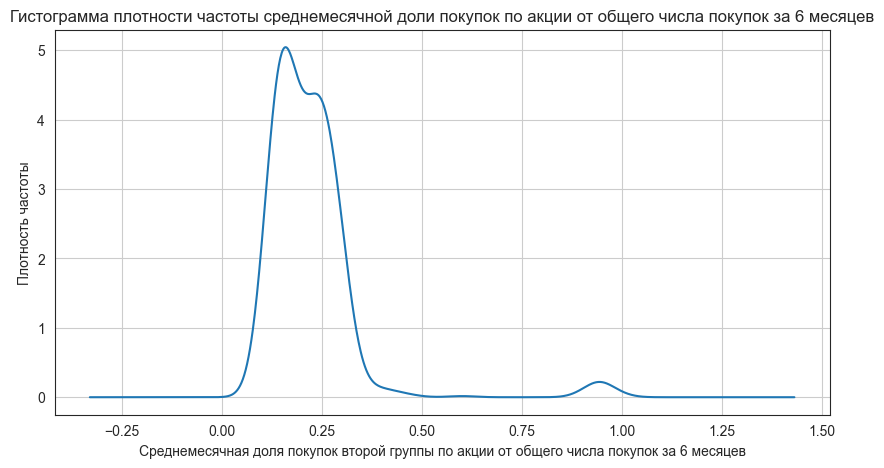

In [154]:
df_group_2['акционные_покупки'].plot.kde(figsize=(10,5), grid=True)
plt.title("Гистограмма плотности частоты среднемесячной доли покупок по акции от общего числа покупок за 6 месяцев")
plt.xlabel('Среднемесячная доля покупок второй группы по акции от общего числа покупок за 6 месяцев')
plt.ylabel('Плотность частоты')
plt.show()

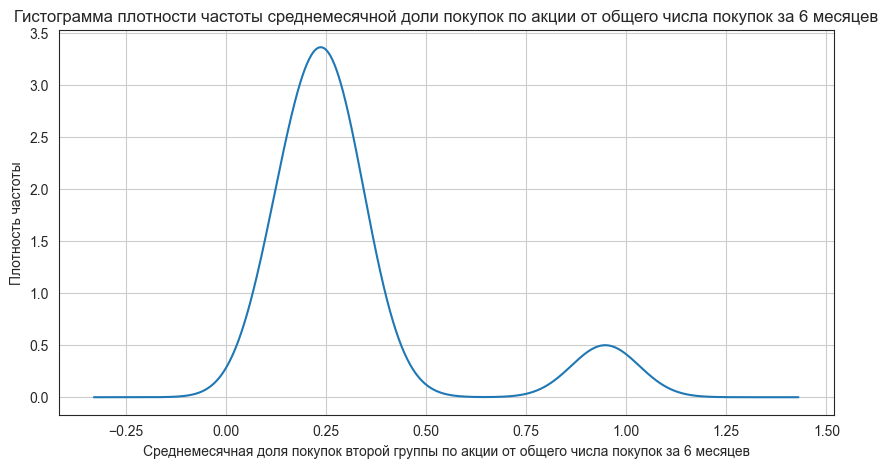

In [155]:
df_group_3['акционные_покупки'].plot.kde(figsize=(10,5), grid=True)
plt.title("Гистограмма плотности частоты среднемесячной доли покупок по акции от общего числа покупок за 6 месяцев")
plt.xlabel('Среднемесячная доля покупок второй группы по акции от общего числа покупок за 6 месяцев')
plt.ylabel('Плотность частоты')
plt.show()

У первой группы значительно больше покупателей, у которых доля покупок по акции почти равна 1, чем у второй и третьей групп

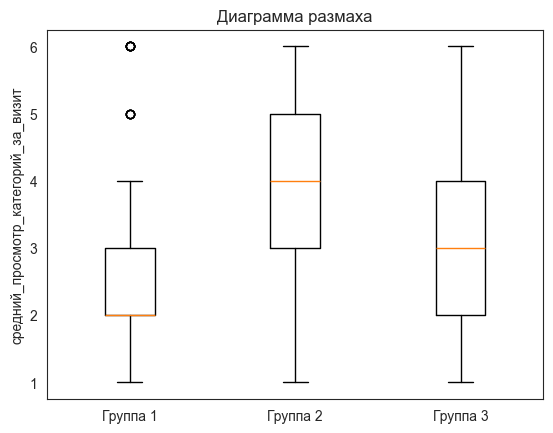

In [156]:
plt.boxplot([df_group_1['средний_просмотр_категорий_за_визит'], 
             df_group_2['средний_просмотр_категорий_за_визит'],
             df_group_3['средний_просмотр_категорий_за_визит']], 
            labels=['Группа 1', 'Группа 2', 'Группа 3'])
plt.title('Диаграмма размаха')
plt.ylabel('средний_просмотр_категорий_за_визит')
plt.show()

In [157]:
df_group_1['средний_просмотр_категорий_за_визит'].value_counts(normalize=True)

средний_просмотр_категорий_за_визит
2    0.400000
3    0.294118
1    0.191176
4    0.079412
6    0.020588
5    0.014706
Name: proportion, dtype: float64

In [158]:
df_group_2['средний_просмотр_категорий_за_визит'].value_counts(normalize=True)

средний_просмотр_категорий_за_визит
3    0.271210
4    0.243394
5    0.215577
2    0.159944
6    0.093185
1    0.016690
Name: proportion, dtype: float64

In [159]:
df_group_3['средний_просмотр_категорий_за_визит'].value_counts(normalize=True)

средний_просмотр_категорий_за_визит
2    0.280423
3    0.243386
4    0.238095
1    0.126984
5    0.063492
6    0.047619
Name: proportion, dtype: float64

У первой группы меньше среднее количество категорий, которое посмотрел покупатель за визит, чем у второй

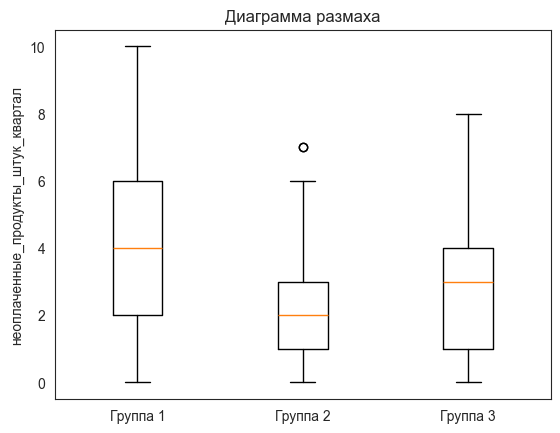

In [160]:
plt.boxplot([df_group_1['неоплаченные_продукты_штук_квартал'], 
             df_group_2['неоплаченные_продукты_штук_квартал'],
             df_group_3['неоплаченные_продукты_штук_квартал']], 
            labels=['Группа 1', 'Группа 2', 'Группа 3'])
plt.title('Диаграмма размаха')
plt.ylabel('неоплаченные_продукты_штук_квартал')
plt.show()

У первой группы общее число неоплаченных товаров в корзине за последние 3 месяца примерно в два раза больше, чем у второй.

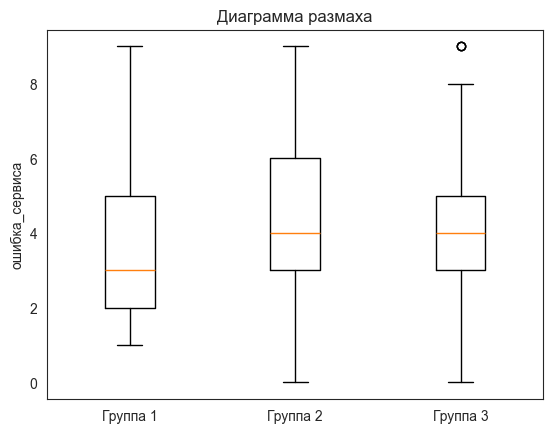

In [161]:
plt.boxplot([df_group_1['ошибка_сервиса'], 
             df_group_2['ошибка_сервиса'],
             df_group_3['ошибка_сервиса']], 
            labels=['Группа 1', 'Группа 2', 'Группа 3'])
plt.title('Диаграмма размаха')
plt.ylabel('ошибка_сервиса')
plt.show()

По числу сбоев, которые коснулись покупателя во время посещения сайта, группы почти не отличаются

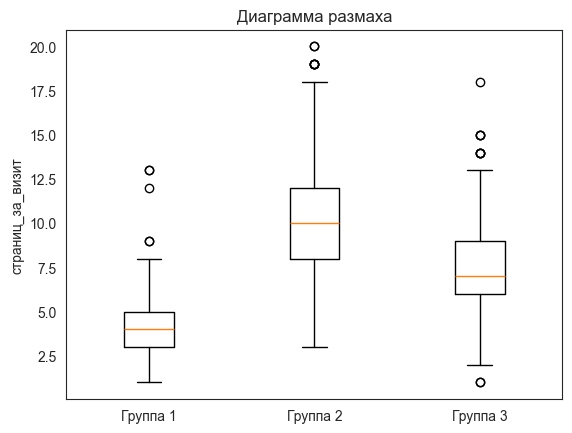

In [162]:
plt.boxplot([df_group_1['страниц_за_визит'], 
             df_group_2['страниц_за_визит'],
             df_group_3['страниц_за_визит']], 
            labels=['Группа 1', 'Группа 2', 'Группа 3'])
plt.title('Диаграмма размаха')
plt.ylabel('страниц_за_визит')
plt.show()

У первой группы значительно меньше среднее количество страниц, просмотренных за один визит, чем у второй и третьей групп

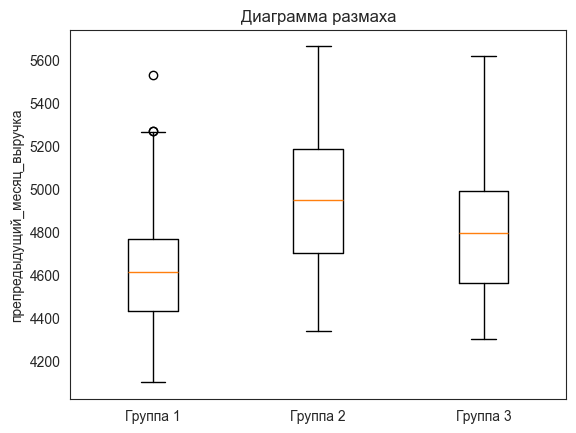

In [163]:
plt.boxplot([df_group_1['препредыдущий_месяц_выручка'], 
             df_group_2['препредыдущий_месяц_выручка'],
             df_group_3['препредыдущий_месяц_выручка']], 
            labels=['Группа 1', 'Группа 2', 'Группа 3'])
plt.title('Диаграмма размаха')
plt.ylabel('препредыдущий_месяц_выручка')
plt.show()

Разница между группами небольшая по данному признаку

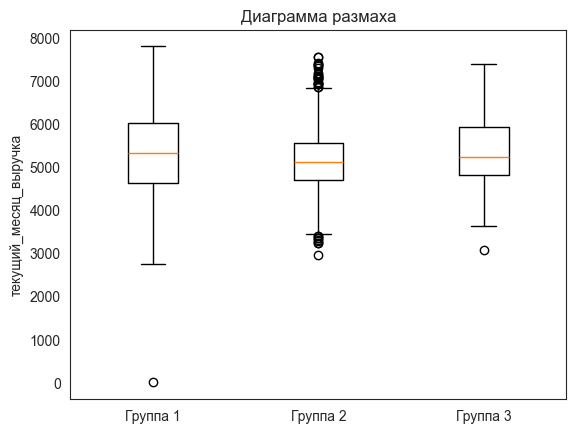

In [164]:
plt.boxplot([df_group_1[df_group_1['текущий_месяц_выручка'] < 100000]['текущий_месяц_выручка'], 
            df_group_2['текущий_месяц_выручка'],
            df_group_3['текущий_месяц_выручка']], 
            labels=['Группа 1', 'Группа 2', 'Группа 3'])
plt.title('Диаграмма размаха')
plt.ylabel('текущий_месяц_выручка')
plt.show()

Разница между группами небольшая по данному признаку

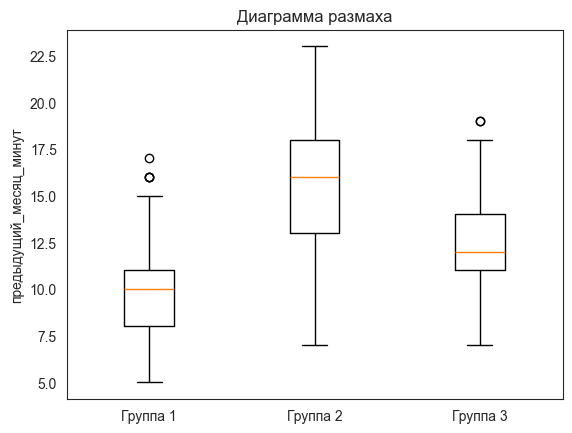

In [165]:
plt.boxplot([df_group_1['предыдущий_месяц_минут'], 
            df_group_2['предыдущий_месяц_минут'],
            df_group_3['предыдущий_месяц_минут']], 
            labels=['Группа 1', 'Группа 2', 'Группа 3'])
plt.title('Диаграмма размаха')
plt.ylabel('предыдущий_месяц_минут')
plt.show()

У первой группы время, проведённое на сайте в предыдущем месяце, значительно меньше, чем у второй группы.

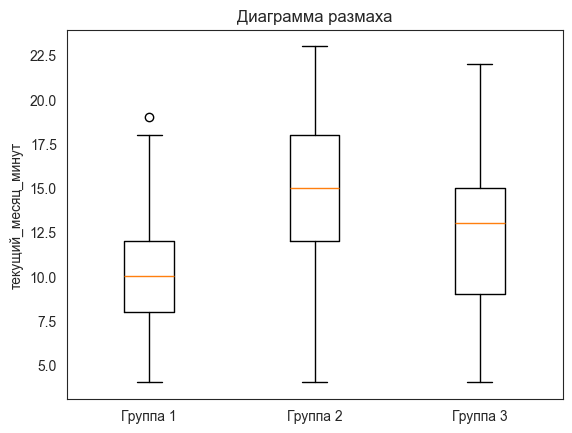

In [166]:
plt.boxplot([df_group_1['текущий_месяц_минут'], 
            df_group_2['текущий_месяц_минут'],
            df_group_3['текущий_месяц_минут']], 
            labels=['Группа 1', 'Группа 2', 'Группа 3'])
plt.title('Диаграмма размаха')
plt.ylabel('текущий_месяц_минут')
plt.show()

У первой группы время, проведённое на сайте в текущем месяце, примерно в полтора раза меньше, чем у второй группы

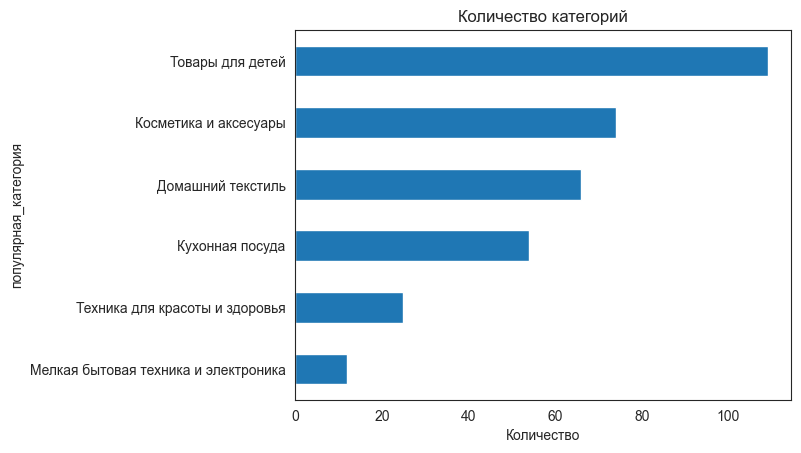

In [167]:
df_group_1['популярная_категория'].value_counts(ascending=True).plot(kind='barh')
plt.title("Количество категорий")
plt.xlabel('Количество')
plt.show()

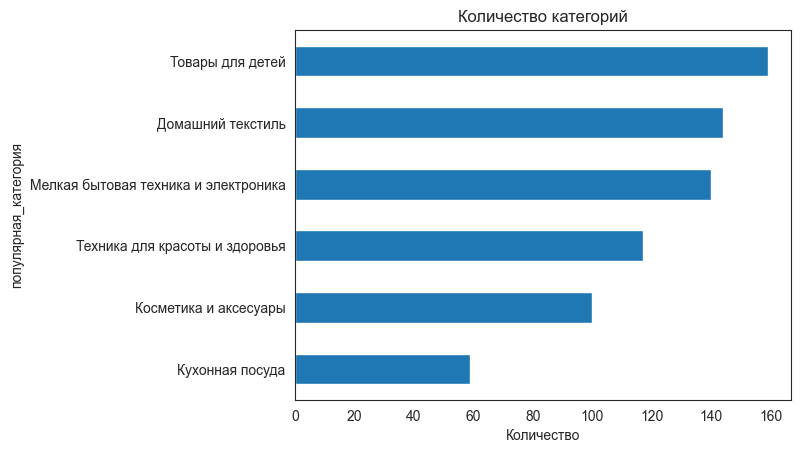

In [168]:
df_group_2['популярная_категория'].value_counts(ascending=True).plot(kind='barh')
plt.title("Количество категорий")
plt.xlabel('Количество')
plt.show()

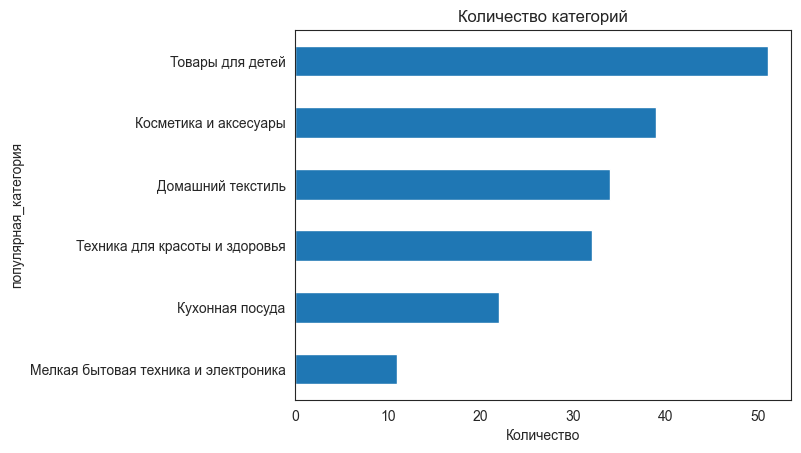

In [169]:
df_group_3['популярная_категория'].value_counts(ascending=True).plot(kind='barh')
plt.title("Количество категорий")
plt.xlabel('Количество')
plt.show()

In [170]:
df_group_1['популярная_категория'].value_counts(normalize=True)

популярная_категория
Товары для детей                        0.320588
Косметика и аксесуары                   0.217647
Домашний текстиль                       0.194118
Кухонная посуда                         0.158824
Техника для красоты и здоровья          0.073529
Мелкая бытовая техника и электроника    0.035294
Name: proportion, dtype: float64

In [171]:
df_group_2['популярная_категория'].value_counts(normalize=True)

популярная_категория
Товары для детей                        0.221140
Домашний текстиль                       0.200278
Мелкая бытовая техника и электроника    0.194715
Техника для красоты и здоровья          0.162726
Косметика и аксесуары                   0.139082
Кухонная посуда                         0.082058
Name: proportion, dtype: float64

In [172]:
df_group_3['популярная_категория'].value_counts(normalize=True)

популярная_категория
Товары для детей                        0.269841
Косметика и аксесуары                   0.206349
Домашний текстиль                       0.179894
Техника для красоты и здоровья          0.169312
Кухонная посуда                         0.116402
Мелкая бытовая техника и электроника    0.058201
Name: proportion, dtype: float64

У всех групп "товары для детей" на первом месте, а "мелкая бытовая техника и электроника" у первой и третьей группы на последнем места, а у второй группы эта категория на втором месте.

In [173]:
df_group_1['тип_сервиса'].value_counts(normalize=True)

тип_сервиса
стандарт    0.635294
премиум     0.364706
Name: proportion, dtype: float64

In [174]:
df_group_2['тип_сервиса'].value_counts(normalize=True)

тип_сервиса
стандарт    0.741307
премиум     0.258693
Name: proportion, dtype: float64

In [175]:
df_group_3['тип_сервиса'].value_counts(normalize=True)

тип_сервиса
стандарт    0.730159
премиум     0.269841
Name: proportion, dtype: float64

Покупатели первой группы чаще выбирают тип сервиса "премиум", чем пользователи из других групп

In [176]:
df_group_1['разрешить_сообщать'].value_counts(normalize=True)

разрешить_сообщать
да     0.738235
нет    0.261765
Name: proportion, dtype: float64

In [177]:
df_group_2['разрешить_сообщать'].value_counts(normalize=True)

разрешить_сообщать
да     0.748261
нет    0.251739
Name: proportion, dtype: float64

In [178]:
df_group_3['разрешить_сообщать'].value_counts(normalize=True)

разрешить_сообщать
да     0.730159
нет    0.269841
Name: proportion, dtype: float64

Разницы между группами по этому признаку нет

**Вывод по группам покупателей**

Покупатели первой группы, у которых большая вероятность снижения покупательской активности, по сравнению с другими группами покупателей меньше просматривают страниц и категорий, меньше времени проводят на сайте и значительно больше покупают по акции. Таким образом, их больше всего интересуют товары по акции и их покупательскую активность можно удержать акциями.

Покупатели третьей группы, у которых средняя вероятность снижения покупательской активности, больше похожи на вторую группу, чем на первую. Покупательскую активность этой группу можно удержать с помощью персонализированных предложений.


## Общий вывод

**При выполнении проекта было сделано:**

- загружены и изучены данные о поведении покупателя на сайте, данные о выручке, которую получает магазин с покупателя, данные о времени, которое покупатель провёл на сайте в течение периода, данные о среднемесячной прибыли покупателя за последние 3 месяца. Переименованы названия столбцов по форме "snake_case". Данные соответствуют описанию задачи, в данных есть целевой признак (класс покупательской активности: «снизилась» или «прежний уровень»)
- провели предобработку данных. Явных дубликатов нет. Был обнаружен только один неявный дубликат в столбце "тип_сервиса" в данных о поведении покупателя на сайте. Заменили слово 'стандартт' на 'стандарт'. Есть выбросы, но аномалий в данных нет.
- провели исследовательский анализ данных. В наборах данных есть признаки с непрерывными и дискретными числовыми переменными. Большинство значений признаков с непрерывными переменными имеют нормальное распределение. Значения у признака «Среднемесячная доля покупок по акции от общего числа покупок за 6 месяцев» имеет бимодальное распределение
- объединили таблицы и провели корреляционный анализ признаков. Между признаками "текущий_месяц_выручка" и "предыдущий_месяц_выручка" была мультиколлинеарность, Для устранения мультиколлинеарности удалили признак "предыдущий_месяц_выручка". Для подсчёта корреляции между признаками разных типов данных использовали библиотеку phik
- для подготовки данных использовали пайплайны с обработкой количественных и категориальных признаков и обучили четыре модели (k-ближайших соседей, дерево решений, логистическая регрессия и метод опорных векторов) с подбором гиперпараметров. Для оценки точности модели выбрали ROC-AUC, т.к. при бинарной классификации и дисбалансе классов целевого признака лучше подходит эта метрика. 
- лучшая точность получилась у модели логистической регрессии. У этой модели небольшое смещение (10%) и небольшой разброс (3%)
- по этой модели оценили важность признаков. Наиблее важные признаки "предыдущий_месяц_минут", "страниц_за_визит", "препредыдущий_месяц_выручка" и "акционные покупки". Наименее важными признаками являются "текущий_месяц_выручка", "разрешать_сообщать" и "длительность".
- построили график важности признаков с помощью метода SHAP. Признаки "разрешить_сообщать" и "текущий_месяц_выручка" мало значимы для модели. Больше всего на целевой признак влияют признаки "предыдущий_месяц_минут", "страниц_за_визит", "акционные_покупки" и "средний_просмотр_категорий_за_визит". Важность признаков совпадает с важностью признаков оцененных моделью.
- добавили в набор данных поле с вероятностью предсказания снижения покупательской активности и данные из набора данных о среднемесячной прибыли по покупателям. По полученным данным сегментировали покупателей на три группы (первая группа с высокой вероятностью снижения покупательской активности, вторая группа с низкой вероятностью снижения покупательской активности и третья группа со средней вероятностью снижения покупательской активности)
- сравнили полученные группы и сделали по ним вывод с предложением по удержанию покупательской активности для групп пользователей с высокой и средней вероятностью снижения покупательской активности